## Getting the data (Ben)

Request all issues with personified token from github_apikey.key file. One can generate a token under https://github.com/settings/tokens

Since the requesting of data takes around 1.5 hours, the already downloaded data is also available on https://rwth-aachen.sciebo.de/s/8MEgD96c6scyjzR

In [63]:
# Imports
import requests
import time
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import nltk
from nltk.tokenize import word_tokenize
import random
import math
import re
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from scipy.stats import ttest_ind
from collections import Counter, defaultdict

In [64]:
TOKEN = "YOUR_PERSONAL_ACCESS_TOKEN" 
if os.path.exists("github_apikey.key"):
    with open("github_apikey.key", 'r') as f:
        TOKEN = f.read().replace("\n", "")

query_template = """
query($cursor: String) {
  rateLimit {
    cost
    remaining
    resetAt
  }
  repository(owner: "%s", name: "%s") {
    issues(
      states: CLOSED, 
      first: 30, 
      after: $cursor
    ) {
      pageInfo {
        hasNextPage
        endCursor
      }
      nodes {
        number
        title
        body
        createdAt
        author {
          login
        }
        labels(first: 20) {
          nodes {
            name
          }
        }
        comments(first: 100) {
          nodes {
            author {
              login
            }
            body
          }
        }
      }
    }
  }
}
"""


In [65]:
def run_query(owner, repo, cursor):
    url = 'https://api.github.com/graphql'
    headers = {"Authorization": f"Bearer {TOKEN}"}
    variables = {"cursor": cursor}
    
    try:
        response = requests.post(url, json={'query': query_template % (owner, repo), 'variables': variables}, headers=headers, timeout=30)
        if response.status_code == 200:
            return response.json()
        else:
            print(f"Error {response.status_code}: {response.text}")
            return None
    except Exception as e:
        print(f"Connection Error: {e}")
        return None

In [66]:
def request_all_issues(owner, repo):
    has_next = True
    cursor = None
    total_issues_processed = 0

    raw_data = open("raw_data_"+repo+".txt", 'w', encoding='utf-8')

    while has_next:
        result = run_query(owner, repo, cursor)
        
        # Check for empty result or connection failure
        if not result:
            print("Network error. Sleeping 5s...")
            time.sleep(5)
            continue

        # Check for GraphQL specific errors (e.g., Bad syntax)
        if 'errors' in result:
            print(f"GraphQL Error: {result['errors']}")
            break # Break loop, otherwise it retries infinitely

        # Check if data exists
        if 'data' not in result or not result['data']:
            print("No data returned.")
            break
        
        data = result['data']
        
        if 'rateLimit' in data:
            rate_limit = data['rateLimit']
            remaining = rate_limit['remaining']
            print(f"Points remaining: {remaining} (Cost: {rate_limit['cost']})")
            
            if remaining < 100:
                print("RATE LIMIT NEAR! Sleeping for 1 hour...")
                time.sleep(3600)
        
        data_repo = data['repository']['issues']
        
        for issue in data_repo['nodes']:
            if not issue or not issue['author'] or not issue['title'] or not issue['body']: 
                continue
            
            issue_id = str(issue['number'])
            issue_author = issue['author']['login']

            issue_title = issue['title'].replace("\n", " ").replace("\r", "")
            issue_body = issue['body'].replace("\n", " ").replace("\r", "")
            issue_date = issue['createdAt']

            label_list = []
            if 'labels' in issue and issue['labels']['nodes']:
                label_list = [l['name'] for l in issue['labels']['nodes']]
            
            label_str = "|".join(label_list)

            raw_data.write(f"issue:{issue_author}\n{label_str}\n{issue_date}\n{issue_title}\n{issue_body}\n")

            if 'comments' in issue and issue['comments']['nodes']:
                for comment in issue['comments']['nodes']:
                    if not comment or not comment['author'] or not comment['body']: 
                        continue
                    
                    comment_author = comment['author']['login']
                    
                    comment_body = comment['body'].replace("\n", " ").replace("\r", "")

                    raw_data.write(f"comment:{comment_author}\n{comment_body}\n")

        # Update Progress
        total_issues_processed += len(data_repo['nodes'])
        has_next = data_repo['pageInfo']['hasNextPage']
        cursor = data_repo['pageInfo']['endCursor']
        
        print(f"Total issues saved: {total_issues_processed}")

    raw_data.close()
    print("Done")

**WARNING: The requesting takes around 1.5 hours**

In [ ]:
request_all_issues("tensorflow", "tensorflow")

In [ ]:
request_all_issues("networkx", "networkx")

In [ ]:
request_all_issues("pandas-dev", "pandas")

## Building the networks (Ben)

In the following we build the tensorflow, pandas, and networkx graph. 

For each graph we connect each commenter of an issue to the issue opener.

In [70]:
G_tensorflow = nx.DiGraph()

def build_graph(raw_data_path):
    read_raw_data = open(raw_data_path, 'r', encoding='utf-8')

    G = nx.DiGraph()

    current_issue_opener = ""

    for line in read_raw_data:
        if line.startswith("issue:"):
            current_issue_opener = line.strip().split(':')[1]
        elif line.startswith("comment:"):
            commentor = line.strip().split(':')[1]
            if commentor != current_issue_opener: 
                G.add_edge(commentor, current_issue_opener)

    read_raw_data.close()
    print(G)
    return G

In [71]:
G_tensorflow = build_graph("raw_data_tensorflow.txt")

DiGraph with 42897 nodes and 112810 edges


In [72]:
G_pandas = build_graph("raw_data_pandas.txt")

DiGraph with 14738 nodes and 31709 edges


In [73]:
G_networkx = build_graph("raw_data_networkx.txt")

DiGraph with 1696 nodes and 2858 edges


**So that every of our measurements is defined we take the largest weakly connect component as the graph.**

**The resulting graphs are:**

In [74]:
largest = max(nx.weakly_connected_components(G_tensorflow), key=len)
G_tensorflow = G_tensorflow.subgraph(largest)

largest = max(nx.weakly_connected_components(G_pandas), key=len)
G_pandas = G_pandas.subgraph(largest)

largest = max(nx.weakly_connected_components(G_networkx), key=len)
G_networkx = G_networkx.subgraph(largest)

print("The tensorflow graph is a " + str(G_tensorflow))
print("The pandas graph is a " + str(G_pandas))
print("The networkx graph is a " + str(G_networkx))

The tensorflow graph is a DiGraph with 42785 nodes and 112749 edges
The pandas graph is a DiGraph with 14648 nodes and 31662 edges
The networkx graph is a DiGraph with 1680 nodes and 2850 edges


**The first thing we want to look at is the degree distribution**

**First we get the in- and out-degrees for all networks**

In [75]:
in_degree_sequence_tensorflow = sorted([d for d in G_tensorflow.in_degree()], key=lambda x: x[1], reverse=True)
out_degree_sequence_tensorflow = sorted([d for d in G_tensorflow.out_degree()], key=lambda x: x[1], reverse=True)

in_degree_sequence_pandas = sorted([d for d in G_pandas.in_degree()], key=lambda x: x[1], reverse=True)
out_degree_sequence_pandas = sorted([d for d in G_pandas.out_degree()], key=lambda x: x[1], reverse=True)

in_degree_sequence_networkx = sorted([d for d in G_networkx.in_degree()], key=lambda x: x[1], reverse=True)
out_degree_sequence_networkx = sorted([d for d in G_networkx.out_degree()], key=lambda x: x[1], reverse=True)

**Then we calculate the median and average degrees**

In [76]:
print("Tensorflow network:")
print(f"The median of the in degree is {in_degree_sequence_tensorflow[int(len(in_degree_sequence_tensorflow)/2)][1]} and also for the out degree it is {out_degree_sequence_tensorflow[int(len(out_degree_sequence_tensorflow)/2)][1]}.")
print(f"The average degree is {sum([x[1] for x in in_degree_sequence_tensorflow])/len(in_degree_sequence_tensorflow):.4f}.")

Tensorflow network:
The median of the in degree is 1 and also for the out degree it is 1.
The average degree is 2.6352.


In [77]:
print("Pandas network:")
print(f"The median of the in degree is {in_degree_sequence_pandas[int(len(in_degree_sequence_pandas)/2)][1]} and also for the out degree it is {out_degree_sequence_pandas[int(len(out_degree_sequence_pandas)/2)][1]}.")
print(f"The average degree is {sum([x[1] for x in in_degree_sequence_pandas])/len(in_degree_sequence_pandas):.4f}.")

Pandas network:
The median of the in degree is 1 and also for the out degree it is 1.
The average degree is 2.1615.


In [78]:
print("NetworkX network:")
print(f"The median of the in degree is {in_degree_sequence_networkx[int(len(in_degree_sequence_networkx)/2)][1]} and also for the out degree it is {out_degree_sequence_networkx[int(len(out_degree_sequence_networkx)/2)][1]}.")
print(f"The average degree is {sum([x[1] for x in in_degree_sequence_networkx])/len(in_degree_sequence_networkx):.4f}.")

NetworkX network:
The median of the in degree is 1 and also for the out degree it is 0.
The average degree is 1.6964.


**Next we plot the in- and out-degree distribution for each network**

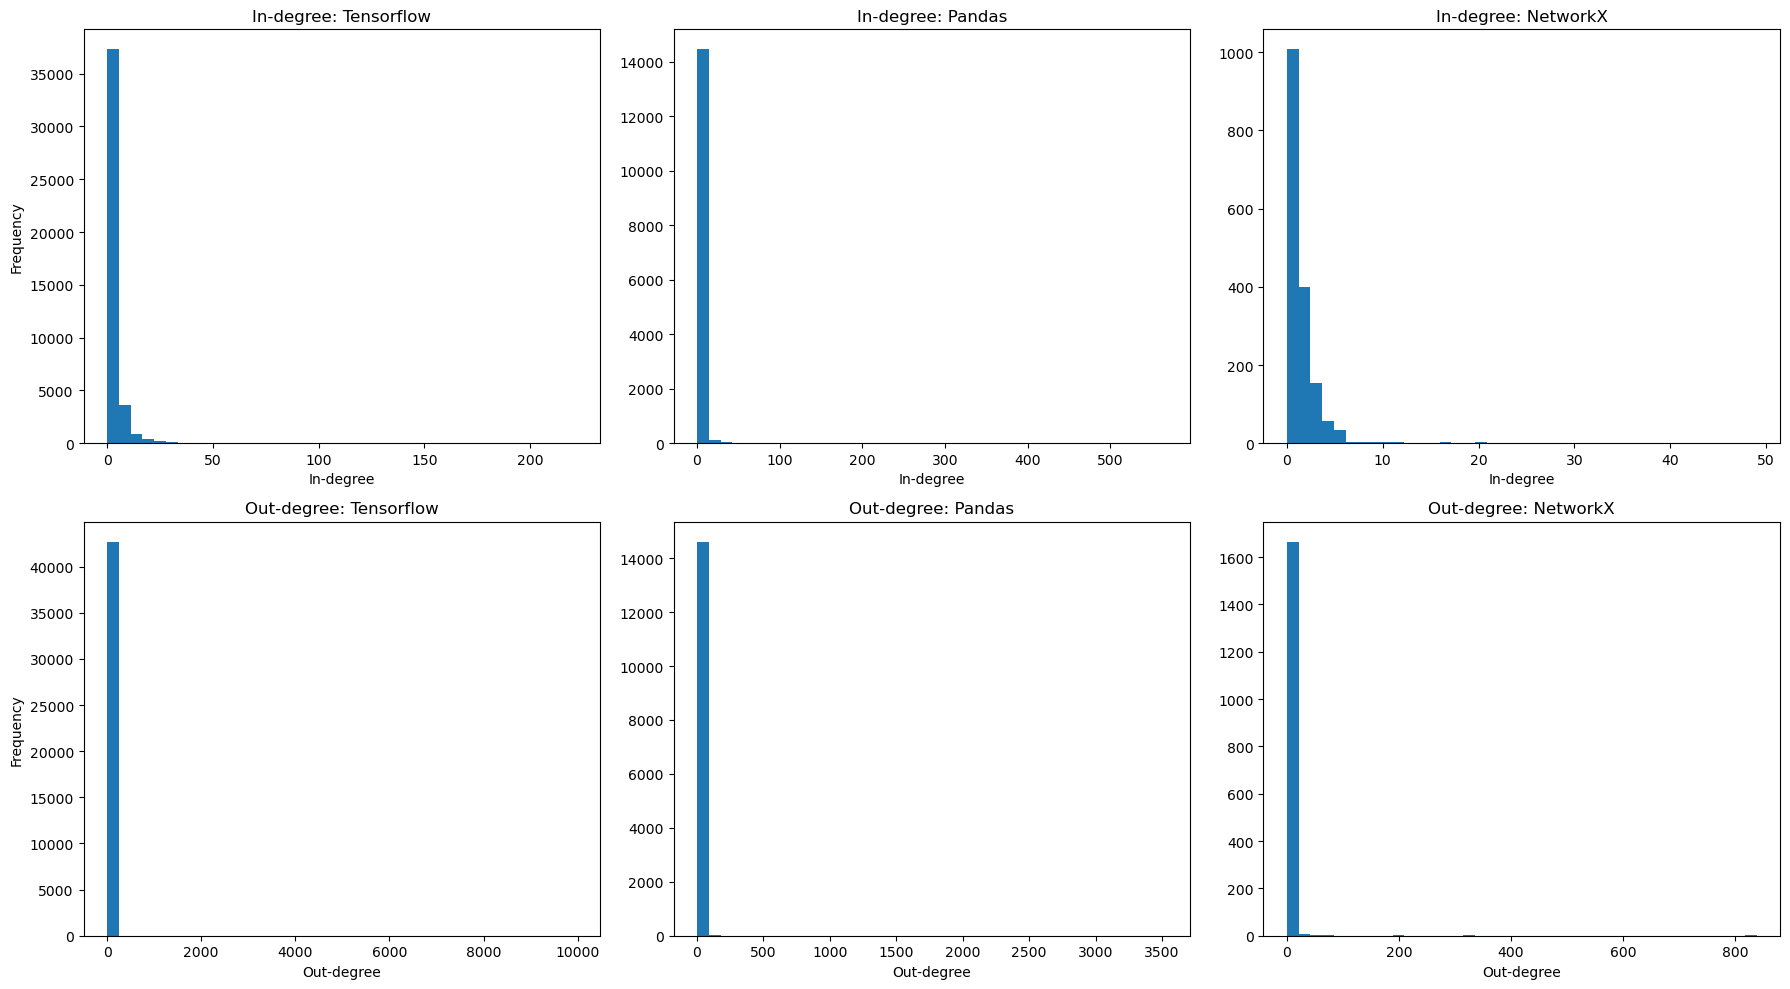

In [79]:
number_bins = 40

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Tensorflow In-degree
axes[0, 0].hist([x[1] for x in in_degree_sequence_tensorflow], bins=number_bins)
axes[0, 0].set_title("In-degree: Tensorflow")
axes[0, 0].set_xlabel("In-degree")
axes[0, 0].set_ylabel("Frequency")

# Pandas In-degree
axes[0, 1].hist([x[1] for x in in_degree_sequence_pandas], bins=number_bins)
axes[0, 1].set_title("In-degree: Pandas")
axes[0, 1].set_xlabel("In-degree")

# NetworkX In-degree
axes[0, 2].hist([x[1] for x in in_degree_sequence_networkx], bins=number_bins)
axes[0, 2].set_title("In-degree: NetworkX")
axes[0, 2].set_xlabel("In-degree")


# Tensorflow Out-degree
axes[1, 0].hist([x[1] for x in out_degree_sequence_tensorflow], bins=number_bins)
axes[1, 0].set_title("Out-degree: Tensorflow")
axes[1, 0].set_xlabel("Out-degree")
axes[1, 0].set_ylabel("Frequency")

# Pandas Out-degree
axes[1, 1].hist([x[1] for x in out_degree_sequence_pandas], bins=number_bins)
axes[1, 1].set_title("Out-degree: Pandas")
axes[1, 1].set_xlabel("Out-degree")

# NetworkX Out-degree
axes[1, 2].hist([x[1] for x in out_degree_sequence_networkx], bins=number_bins)
axes[1, 2].set_title("Out-degree: NetworkX")
axes[1, 2].set_xlabel("Out-degree")

plt.tight_layout()
plt.show()

We clearly see that we have scale free networks

**Next we calculate the percentages of nodes that have an in- and out-degree of 0 or 1.**

In [80]:
print(f"The percantage of nodes that have an in-degree of 0 or 1 in the tensorflow network is {len([x for x in in_degree_sequence_tensorflow if x[1]<=1])/len(in_degree_sequence_tensorflow)*100:.2f}%.")
print(f"The percantage of nodes that have an out-degree of 0 or 1 in the tensorflow network is {len([x for x in out_degree_sequence_tensorflow if x[1]<=1])/len(out_degree_sequence_tensorflow)*100:.2f}%.")

The percantage of nodes that have an in-degree of 0 or 1 in the tensorflow network is 56.75%.
The percantage of nodes that have an out-degree of 0 or 1 in the tensorflow network is 85.03%.


In [81]:
print(f"The percantage of nodes that have an in-degree of 0 or 1 in the pandas network is {len([x for x in in_degree_sequence_pandas if x[1]<=1])/len(in_degree_sequence_pandas)*100:.2f}%.")
print(f"The percantage of nodes that have an out-degree of 0 or 1 in the pandas network is {len([x for x in out_degree_sequence_pandas if x[1]<=1])/len(out_degree_sequence_pandas)*100:.2f}%.")

The percantage of nodes that have an in-degree of 0 or 1 in the pandas network is 59.45%.
The percantage of nodes that have an out-degree of 0 or 1 in the pandas network is 87.54%.


In [82]:
print(f"The percantage of nodes that have an in-degree of 0 or 1 in the networkx network is {len([x for x in in_degree_sequence_networkx if x[1]<=1])/len(in_degree_sequence_networkx)*100:.2f}%.")
print(f"The percantage of nodes that have an out-degree of 0 or 1 in the networkx network is {len([x for x in out_degree_sequence_networkx if x[1]<=1])/len(out_degree_sequence_networkx)*100:.2f}%.")

The percantage of nodes that have an in-degree of 0 or 1 in the networkx network is 60.00%.
The percantage of nodes that have an out-degree of 0 or 1 in the networkx network is 92.80%.


**Next we want to check if the scale free property when we only look at nodes that have a certain number of interactions (we look at the top ~5% of nodes)**

In [83]:
cutoff = 10

print("Tensorflow network:")
print(f"The number of nodes that have an in-degree of less than {cutoff} is {len([x for x in in_degree_sequence_tensorflow if x[1]<cutoff])/len(in_degree_sequence_tensorflow)*100:.2f}%.")
print(f"The number of nodes that have an out-degree of less than {cutoff} is {len([x for x in out_degree_sequence_tensorflow if x[1]<cutoff])/len(out_degree_sequence_tensorflow)*100:.2f}%.")

Tensorflow network:
The number of nodes that have an in-degree of less than 10 is 94.21%.
The number of nodes that have an out-degree of less than 10 is 98.84%.


In [84]:
print("Pandas network:")
print(f"The number of nodes that have an in-degree of less than {cutoff} is {len([x for x in in_degree_sequence_pandas if x[1]<cutoff])/len(in_degree_sequence_pandas)*100:.2f}%.")
print(f"The number of nodes that have an out-degree of less than {cutoff} is {len([x for x in out_degree_sequence_pandas if x[1]<cutoff])/len(out_degree_sequence_pandas)*100:.2f}%.")

Pandas network:
The number of nodes that have an in-degree of less than 10 is 97.03%.
The number of nodes that have an out-degree of less than 10 is 98.94%.


In [85]:
print("Networkx network:")
print(f"The number of nodes that have an in-degree of less than {cutoff} is {len([x for x in in_degree_sequence_networkx if x[1]<cutoff])/len(in_degree_sequence_networkx)*100:.2f}%.")
print(f"The number of nodes that have an out-degree of less than {cutoff} is {len([x for x in out_degree_sequence_networkx if x[1]<cutoff])/len(out_degree_sequence_networkx)*100:.2f}%.")

Networkx network:
The number of nodes that have an in-degree of less than 10 is 98.81%.
The number of nodes that have an out-degree of less than 10 is 98.87%.


In [86]:
in_tensorflow_greater_cutoff = [d for d in G_tensorflow.in_degree() if d[1] >= cutoff]
out_tensorflow_greater_cutoff = [d for d in G_tensorflow.out_degree() if d[1] >= cutoff]

in_pandas_greater_cutoff = [d for d in G_pandas.in_degree() if d[1] >= cutoff]
out_pandas_greater_cutoff = [d for d in G_pandas.out_degree() if d[1] >= cutoff]

in_networkx_greater_cutoff = [d for d in G_networkx.in_degree() if d[1] >= cutoff]
out_networkx_greater_cutoff = [d for d in G_networkx.out_degree() if d[1] >= cutoff]

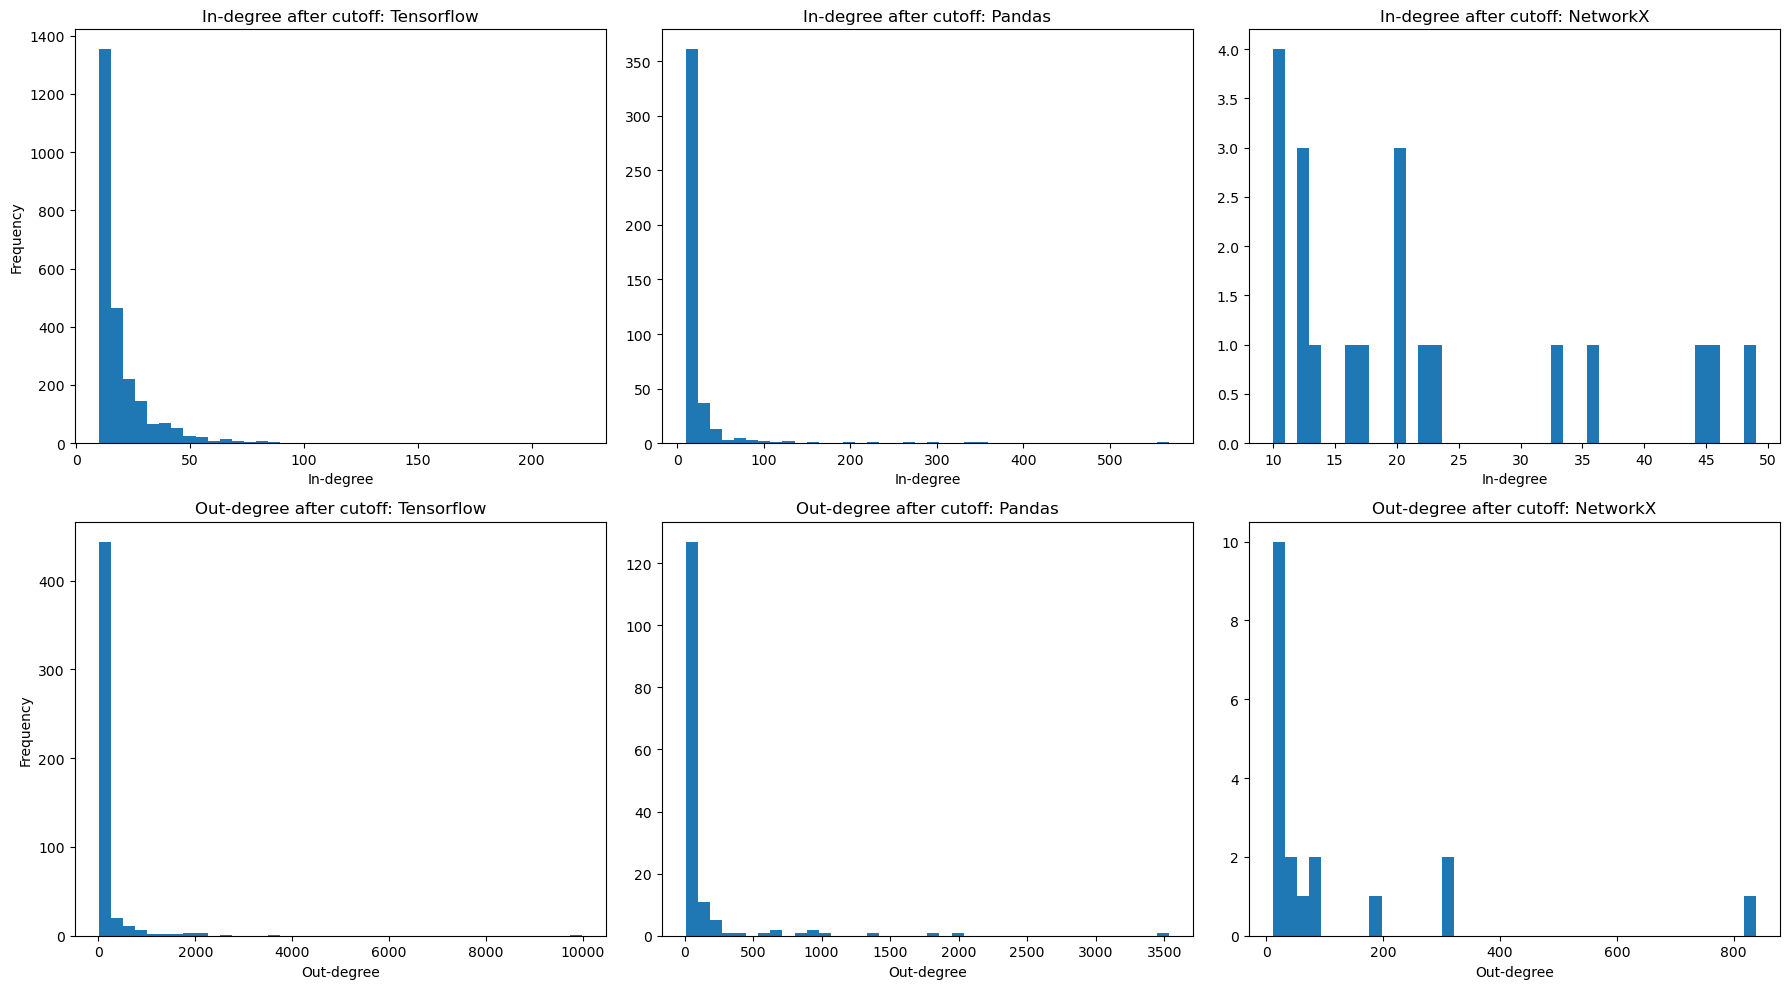

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Tensorflow In-degree
axes[0, 0].hist([x[1] for x in in_tensorflow_greater_cutoff], bins=number_bins)
axes[0, 0].set_title("In-degree after cutoff: Tensorflow")
axes[0, 0].set_xlabel("In-degree")
axes[0, 0].set_ylabel("Frequency")

# Pandas In-degree
axes[0, 1].hist([x[1] for x in in_pandas_greater_cutoff], bins=number_bins)
axes[0, 1].set_title("In-degree after cutoff: Pandas")
axes[0, 1].set_xlabel("In-degree")

# NetworkX In-degree
axes[0, 2].hist([x[1] for x in in_networkx_greater_cutoff], bins=number_bins)
axes[0, 2].set_title("In-degree after cutoff: NetworkX")
axes[0, 2].set_xlabel("In-degree")


# Tensorflow Out-degree
axes[1, 0].hist([x[1] for x in out_tensorflow_greater_cutoff], bins=number_bins)
axes[1, 0].set_title("Out-degree after cutoff: Tensorflow")
axes[1, 0].set_xlabel("Out-degree")
axes[1, 0].set_ylabel("Frequency")

# Pandas Out-degree
axes[1, 1].hist([x[1] for x in out_pandas_greater_cutoff], bins=number_bins)
axes[1, 1].set_title("Out-degree after cutoff: Pandas")
axes[1, 1].set_xlabel("Out-degree")

# NetworkX Out-degree
axes[1, 2].hist([x[1] for x in out_networkx_greater_cutoff], bins=number_bins)
axes[1, 2].set_title("Out-degree after cutoff: NetworkX")
axes[1, 2].set_xlabel("Out-degree")

plt.tight_layout()
plt.show()

We see that the scale free still mostly holds in the top ~5% of users.

**Next we want to look at the top 10 users for each network regarding in- and out-degree.**

In [88]:
df_top10_in_tensorflow = pd.DataFrame(in_degree_sequence_tensorflow[0:10], columns=('User', ''))
df_top10_out_tensorflow = pd.DataFrame(out_degree_sequence_tensorflow[0:10], columns=('User', ''))

df_top10_in_pandas = pd.DataFrame(in_degree_sequence_pandas[0:10], columns=('User', ''))
df_top10_out_pandas = pd.DataFrame(out_degree_sequence_pandas[0:10], columns=('User', ''))

df_top10_in_networkx = pd.DataFrame(in_degree_sequence_networkx[0:10], columns=('User', ''))
df_top10_out_networkx = pd.DataFrame(out_degree_sequence_networkx[0:10], columns=('User', ''))

frames = {
    ('TensorFlow', 'In-Degree'): df_top10_in_tensorflow,
    ('TensorFlow', 'Out-Degree'): df_top10_out_tensorflow,
    ('Pandas', 'In-Degree'): df_top10_in_pandas,
    ('Pandas', 'Out-Degree'): df_top10_out_pandas,
    ('NetworkX', 'In-Degree'): df_top10_in_networkx,
    ('NetworkX', 'Out-Degree'): df_top10_out_networkx,
}

combined_df = pd.concat(
    [df.reset_index(drop=True) for df in frames.values()], 
    axis=1, 
    keys=frames.keys()
)

print(combined_df.to_string(index=False))

     TensorFlow                                       Pandas                                  NetworkX                      
      In-Degree           Out-Degree               In-Degree             Out-Degree          In-Degree        Out-Degree    
           User                 User                    User                   User               User              User    
     yaroslavvb 222 google-ml-butler 9979            jreback 568            jreback 3534       dschult 49        dschult 838
      cancan101 189 tensorflowbutler 3513 jorisvandenbossche 345          mroeschke 1983       rossbar 46        hagberg 320
       ppwwyyxx 174   github-actions 2662      TomAugspurger 334      TomAugspurger 1835       MridulS 45        rossbar 316
     alanpurple 146       tilakrayal 2123       MarcoGorelli 291 jorisvandenbossche 1415 networkx-trac 36        MridulS 194
dynamicwebpaige 137           ymodak 2100     datapythonista 265         rhshadrach 1062 jarrodmillman 33       chebee7i  81


**Now we want to plot the in-degree vs out-degree for all networks and additionally mark all the users present in the top 50 of contributors on the respective Github pages**

In [89]:
def get_top_contributors(owner, repo):
    url = f"https://api.github.com/repos/{owner}/{repo}/contributors?per_page=50"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        return [user['login'] for user in data]
    else:
        print(f"Error fetching {repo}: Status {response.status_code}")
        print("You may have hit the GitHub API rate limit.")
        return []

top_50_tf = get_top_contributors('tensorflow', 'tensorflow')
top_50_pandas = get_top_contributors('pandas-dev', 'pandas')
top_50_nx = get_top_contributors('networkx', 'networkx')

print(f"Fetched: {len(top_50_tf)} TF users, {len(top_50_pandas)} Pandas users, {len(top_50_nx)} NX users.")

Fetched: 50 TF users, 50 Pandas users, 50 NX users.


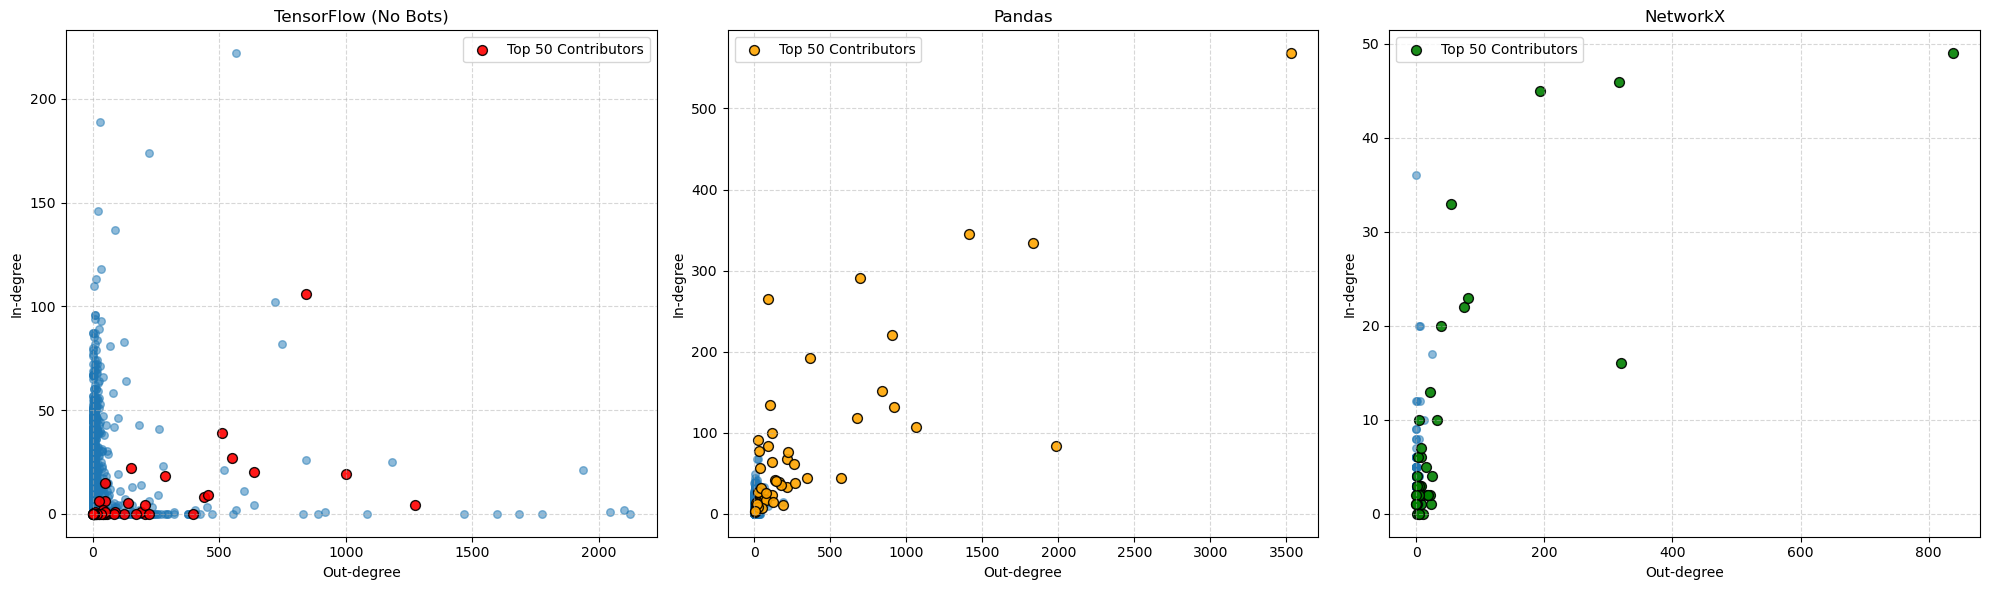

In [90]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

# TensorFlow
in_degrees = dict(G_tensorflow.in_degree())
out_degrees = dict(G_tensorflow.out_degree())
bots = ['google-ml-butler', 'tensorflowbutler', 'github-actions', 'tensorflow-bot']
nodes = list(G_tensorflow.nodes())

# Separate data into two groups
x_rest, y_rest = [], []
x_top, y_top = [], []

for n in nodes:
    if n in bots:
        continue # Skip bots
    
    x = out_degrees[n]
    y = in_degrees[n]
    
    if n in top_50_tf:
        x_top.append(x)
        y_top.append(y)
    else:
        x_rest.append(x)
        y_rest.append(y)

# Plot "Rest" in grey/blue
axs[0].scatter(x_rest, y_rest, alpha=0.5, s=30, color='tab:blue')
# Plot "Top 50" in distinct red 
axs[0].scatter(x_top, y_top, alpha=0.9, s=50, c='red', edgecolors='black', label='Top 50 Contributors')

axs[0].set_xlabel("Out-degree")
axs[0].set_ylabel("In-degree")
axs[0].set_title("TensorFlow (No Bots)")
axs[0].legend()
axs[0].grid(True, linestyle="--", alpha=0.5)

# Pandas
in_degrees = dict(G_pandas.in_degree())
out_degrees = dict(G_pandas.out_degree())
nodes = list(G_pandas.nodes())

x_rest, y_rest = [], []
x_top, y_top = [], []

for n in nodes:
    x = out_degrees[n]
    y = in_degrees[n]
    
    if n in top_50_pandas:
        x_top.append(x)
        y_top.append(y)
    else:
        x_rest.append(x)
        y_rest.append(y)

axs[1].scatter(x_rest, y_rest, alpha=0.5, s=30, color='tab:blue')
axs[1].scatter(x_top, y_top, alpha=0.9, s=50, c='orange', edgecolors='black', label='Top 50 Contributors')

axs[1].set_xlabel("Out-degree")
axs[1].set_ylabel("In-degree")
axs[1].set_title("Pandas")
axs[1].legend()
axs[1].grid(True, linestyle="--", alpha=0.5)

# NetworkX
in_degrees = dict(G_networkx.in_degree())
out_degrees = dict(G_networkx.out_degree())
nodes = list(G_networkx.nodes())

x_rest, y_rest = [], []
x_top, y_top = [], []

for n in nodes:
    x = out_degrees[n]
    y = in_degrees[n]
    
    if n in top_50_nx:
        x_top.append(x)
        y_top.append(y)
    else:
        x_rest.append(x)
        y_rest.append(y)

axs[2].scatter(x_rest, y_rest, alpha=0.5, s=30, color='tab:blue')
axs[2].scatter(x_top, y_top, alpha=0.9, s=50, c='green', edgecolors='black', label='Top 50 Contributors')

axs[2].set_xlabel("Out-degree")
axs[2].set_ylabel("In-degree")
axs[2].set_title("NetworkX")
axs[2].legend()
axs[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

We see that for Pandas and NetworkX, high in-degree correlates with high out-degree and being in the top 50 contributors, for TensorFlow this is not the case. For TensorFlow we also filtered out the bots to more accurately compare the networks.

**Next we look how many users are present in 2 or all of the networks and plot the degrees for these users in each network against one another**

In [91]:
both_tensorflow_pandas = [d for d in G_tensorflow.nodes() if d in G_pandas]
both_tensorflow_networkx = [d for d in G_tensorflow.nodes() if d in G_networkx]
both_pandas_networkx = [d for d in G_pandas.nodes() if d in G_networkx]
in_all_networks = [d for d in G_tensorflow.nodes() if d in G_pandas and d in G_networkx]

print(f"There are {len(both_tensorflow_pandas)} users that appear in both the Tensorflow, as well as in the pandas network.")
print(f"There are {len(both_tensorflow_networkx)} users that appear in both the Tensorflow, as well as in the Networkx network.")
print(f"There are {len(both_pandas_networkx)} users that appear in both the pandas, as well as in the Networkx network.")
print(f"There are {len(in_all_networks)} users that appear in all 3 networks.")

There are 1028 users that appear in both the Tensorflow, as well as in the pandas network.
There are 121 users that appear in both the Tensorflow, as well as in the Networkx network.
There are 205 users that appear in both the pandas, as well as in the Networkx network.
There are 42 users that appear in all 3 networks.


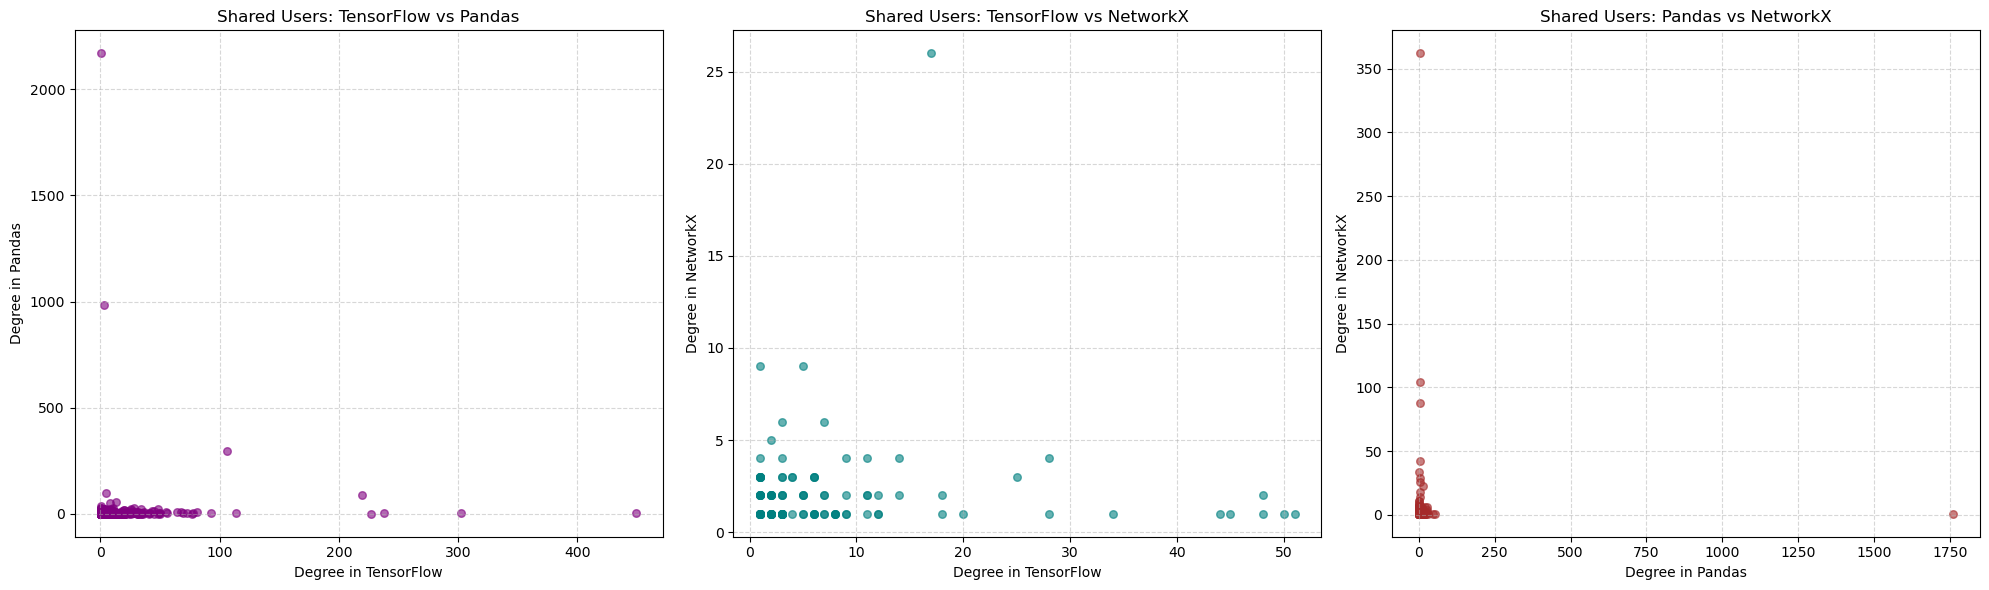

In [92]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: TensorFlow vs Pandas ---
degree_tensorflow = []
degree_pandas = []

for user in both_tensorflow_pandas:
    degree_tensorflow.append(G_tensorflow.degree()[user])
    degree_pandas.append(G_pandas.degree()[user])

axs[0].scatter(degree_tensorflow, degree_pandas, alpha=0.6, s=30, color='purple')
axs[0].set_xlabel("Degree in TensorFlow")
axs[0].set_ylabel("Degree in Pandas")
axs[0].set_title("Shared Users: TensorFlow vs Pandas")
axs[0].grid(True, linestyle="--", alpha=0.5)


# --- Plot 2: TensorFlow vs NetworkX ---
degree_tensorflow = []
degree_networkx = []

for user in both_tensorflow_networkx:
    degree_tensorflow.append(G_tensorflow.degree()[user])
    degree_networkx.append(G_networkx.degree()[user])

axs[1].scatter(degree_tensorflow, degree_networkx, alpha=0.6, s=30, color='teal')
axs[1].set_xlabel("Degree in TensorFlow")
axs[1].set_ylabel("Degree in NetworkX")
axs[1].set_title("Shared Users: TensorFlow vs NetworkX")
axs[1].grid(True, linestyle="--", alpha=0.5)


# --- Plot 3: Pandas vs NetworkX ---
degree_pandas = []
degree_networkx = []

for user in both_pandas_networkx:
    degree_pandas.append(G_pandas.degree()[user])
    degree_networkx.append(G_networkx.degree()[user])

axs[2].scatter(degree_pandas, degree_networkx, alpha=0.6, s=30, color='brown')
axs[2].set_xlabel("Degree in Pandas")
axs[2].set_ylabel("Degree in NetworkX")
axs[2].set_title("Shared Users: Pandas vs NetworkX")
axs[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

We see that a high degree in one network doesn't really imply a high degree in another network.

**We also tried to look at communities, and we got relatively high modularity with the louvain algorithm, however we couldn't really find any meaning behind these communities, so we didn't include them in the report**

In [93]:
def calculate_modularity_list(G, partition):

    nodes_in_partition = [x for y in partition for x in y]

    G_partitioned = G.subgraph(nodes_in_partition).copy()
    
    L = G_partitioned.number_of_edges()

    two_L = 2.0 * L
    
    # Calculate Modularity using Equation 9.12
    # M = Σ_c [ (L_c / L) - (k_c / 2L)^2 ]
    
    degrees = dict(G_partitioned.degree())
    
    modularity_sum = 0.0
    for nodes_in_comm in partition:

        comm_subgraph = G_partitioned.subgraph(nodes_in_comm)
        L_c = comm_subgraph.number_of_edges()
        
        k_c = 0.0
        for node in nodes_in_comm:
            k_c += degrees[node]
            
        term_1 = L_c / L
        term_2 = (k_c / two_L)**2
        
        modularity_sum += (term_1 - term_2)
        
    M = modularity_sum
        
    return M

In [94]:
G_networkx_und = G_networkx.to_undirected()
louv_comm_networkx = nx.community.louvain_communities(G_networkx_und, seed=42)
G_pandas_und = G_pandas.to_undirected()
louv_comm_pandas = nx.community.louvain_communities(G_pandas_und, seed=42)    
G_tensorflow_und = G_tensorflow.to_undirected()
louv_comm_tensorflow = nx.community.louvain_communities(G_tensorflow_und, seed=42)        

In [95]:
print(f"For TensorFlow we get {len(louv_comm_tensorflow)} communities and a modularity score of {calculate_modularity_list(G_tensorflow_und, louv_comm_tensorflow)}.")
print(f"For Pandas we get {len(louv_comm_pandas)} communities and a modularity score of {calculate_modularity_list(G_pandas_und, louv_comm_pandas)}.")
print(f"For NetworkX we get {len(louv_comm_networkx)} communities and a modularity score of {calculate_modularity_list(G_networkx_und, louv_comm_networkx)}.")

For TensorFlow we get 80 communities and a modularity score of 0.5157712844403547.
For Pandas we get 33 communities and a modularity score of 0.5048793921101735.
For NetworkX we get 16 communities and a modularity score of 0.528709927224534.


In [96]:
pose = nx.forceatlas2_layout(G_networkx_und)

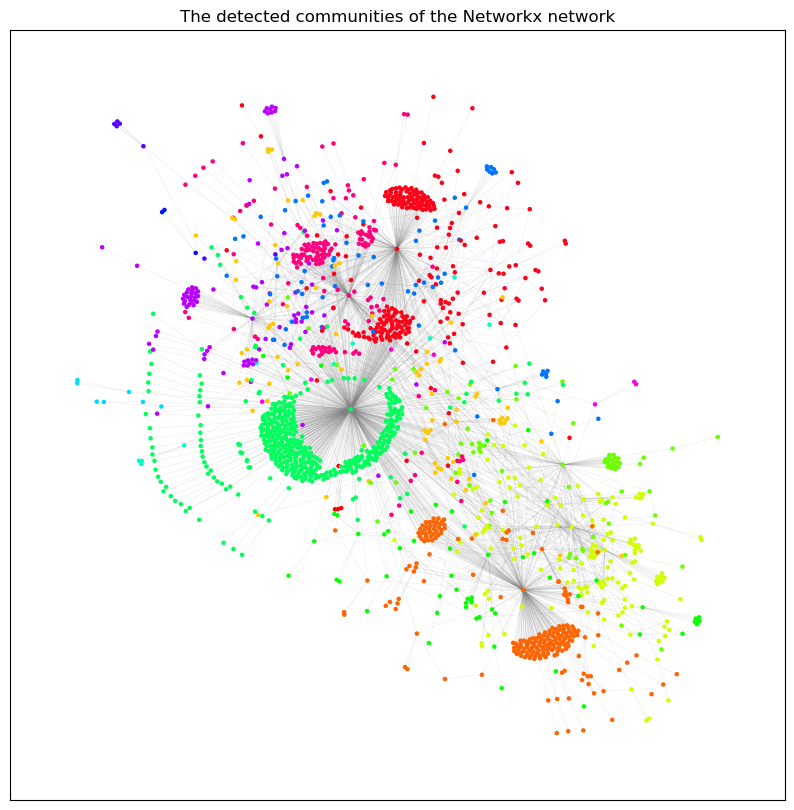

In [97]:
cmap = plt.get_cmap('hsv', len(louv_comm_networkx))

color_map = []

for n in G_networkx_und.nodes():
    for i in range(len(louv_comm_networkx)):
        if n in louv_comm_networkx[i]:
            color_map.append(cmap(i))
            break

plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(
    G_networkx_und, 
    pos=pose, 
    node_color=color_map,
    node_size=5,
    alpha=1.0
)
nx.draw_networkx_edges(
    G_networkx_und, 
    pos=pose, 
    edge_color='gray',  
    width=0.3,
    alpha=0.2
)
plt.title("The detected communities of the Networkx network")
plt.show()

**We also tried to work with NLTK, however we noticed that it is a bit too slow for our case, so for TF-IDF we used some other libraries as can be seen in the next chapter**

In [98]:
def write_top_ten(path_read, path, in_sequence, out_sequence):
    read_raw_data = open(path_read, 'r', encoding='utf-8')

    for (user, _) in in_sequence[0:10]:
        read_raw_data.seek(0)

        all_issues = ""

        iterator = iter(read_raw_data)    

        for line in iterator:
            if line.startswith("issue:" + user):
                next(iterator)
                next(iterator)
                cur_issue = next(iterator)
                cur_issue += next(iterator)

                all_issues += cur_issue

        with open(path + "in-" + user, 'w', encoding='utf-8') as f:
            f.write(all_issues)


    for (user, _) in out_sequence[0:10]:
        read_raw_data.seek(0)

        all_comments = ""

        iterator = iter(read_raw_data)    

        for line in iterator:
            if line.startswith("comment:" + user):
                cur_comment = next(iterator)

                all_comments += cur_comment

        with open(path + "out-" + user, 'w', encoding='utf-8') as f:
            f.write(all_comments)

    read_raw_data.close()

In [99]:
write_top_ten("raw_data_tensorflow.txt", "top10-tensorflow/", in_degree_sequence_tensorflow, out_degree_sequence_tensorflow)
write_top_ten("raw_data_pandas.txt", "top10-pandas/", in_degree_sequence_pandas, out_degree_sequence_pandas)
write_top_ten("raw_data_networkx.txt", "top10-networkx/", in_degree_sequence_networkx, out_degree_sequence_networkx)

In [100]:
path = "top10-networkx/"

def text_without_stopwords(text):
    stopwords = nltk.corpus.stopwords.words('english')
    return [w.lower() for w in text if w.lower() not in stopwords and w.isalpha()]
     
files = os.listdir(path)

for file in files:
    with open(path + file, 'r', encoding="utf-8") as f:
        tokenizer = nltk.TreebankWordTokenizer()

        tokens = tokenizer.tokenize(f.read())
        print(nltk.FreqDist(text_without_stopwords(tokens)).most_common(50))

[('graph', 46), ('function', 45), ('nodes', 41), ('like', 41), ('g', 40), ('code', 40), ('edge', 33), ('would', 33), ('add', 33), ('use', 32), ('data', 29), ('version', 29), ('edges', 28), ('node', 28), ('file', 28), ('line', 27), ('test', 27), ('example', 26), ('see', 26), ('tests', 25), ('new', 25), ('think', 24), ('none', 24), ('error', 24), ('docs', 24), ('one', 23), ('https', 23), ('could', 23), ('x', 23), ('change', 22), ('python', 22), ('also', 21), ('directed', 21), ('make', 20), ('return', 20), ('need', 20), ('name', 20), ('import', 20), ('used', 19), ('order', 19), ('n', 18), ('instead', 18), ('multigraph', 18), ('way', 18), ('allow', 18), ('functions', 18), ('networkx', 18), ('iterator', 17), ('u', 17), ('documentation', 17)]
[('file', 192), ('line', 164), ('g', 116), ('graph', 83), ('would', 56), ('https', 52), ('class', 50), ('test', 41), ('function', 40), ('functions', 37), ('example', 37), ('one', 33), ('list', 32), ('object', 32), ('sorted', 32), ('see', 31), ('node', 3

In [101]:
for file in files:
    with open(path + file, 'r', encoding="utf-8") as f:
        tokenizer = nltk.TreebankWordTokenizer()

        tokens = tokenizer.tokenize(f.read())

        text1_without = text_without_stopwords(tokens)

        all_bigrams = list(nltk.bigrams(text1_without))
            
        fdist_bigrams = nltk.FreqDist(all_bigrams)

        print(fdist_bigrams.most_common(50))

[(('file', 'line'), 17), (('looks', 'like'), 15), (('g', 'g'), 10), (('dispatch', 'decorators'), 10), (('u', 'v'), 8), (('n', 'nbr'), 7), (('directed', 'multigraph'), 7), (('internalerror', 'file'), 7), (('line', 'internalerror'), 7), (('edges', 'nodes'), 6), (('order', 'nodes'), 6), (('without', 'dispatch'), 6), (('see', 'also'), 5), (('data', 'none'), 5), (('shallow', 'copy'), 5), (('traceback', 'recent'), 5), (('recent', 'call'), 5), (('call', 'last'), 5), (('multigraph', 'directed'), 5), (('data', 'true'), 4), (('nbr', 'data'), 4), (('iterator', 'edge'), 4), (('recent', 'release'), 4), (('even', 'though'), 4), (('neighbors', 'node'), 4), (('base', 'class'), 4), (('something', 'like'), 4), (('numpy', 'import'), 4), (('id', 'obj'), 4), (('obj', 'obj'), 4), (('obj', 'isinstance'), 4), (('isinstance', 'obj'), 4), (('import', 'networkx'), 4), (('last', 'file'), 4), (('line', 'module'), 4), (('decorators', 'µs'), 4), (('python', 'version'), 4), (('circular', 'import'), 4), (('one', 'exam

# Applying TF-IDF and Sentiment Valence (Duco)

In the following part, in general we treat one issue with all its comments as a document, and one repository as a corpus. Lateron we will merge all the corpa to gain one big ""Github corpus", we can then categories our repos as communities, which we can then do analysis on.   
We compute TF-IDF and sentiment valence, and then analyze issues and repositories.

## Pre-processing the data

Pre-process the data, takes in all the .txt files from all repo's and turns them into a pre-processed .csv file containing all the text per issue.

#### Loading the TXT data into pandas dataframes

In [102]:
def load_txt_data(data_path: str, repo_name: str):
    rows = []

    f =  open(data_path, "r", encoding="utf-8")
    lines = f.read().splitlines()

    f.close()

    i = 0
    issue_id = 0
    n = len(lines)
    current_issue_opener = None

    while i < n:
        line = lines[i]
        # If the text is an issue.
        if line.startswith("issue:"):
            issue_id += 1

            opener = line[len("issue:"):]
            issue_type = lines[i + 1]
            date = lines[i + 2]
            title = lines[i + 3]
            body = lines[i + 4]

            current_issue_opener = opener

            rows.append({
                "type": "issue",
                "issue_type": (issue_type if issue_type else "N/A"),
                "issue_date": date,
                "opener": opener,
                "title": title,
                "body": body,
                # issues are opened by the opener, put it in commenter column for easy comparison
                "commenter": opener,
                "issue_id": f"{repo_name}-{issue_id}"
            })

            i += 5
            continue
        # If the text is a comment.
        if line.startswith("comment:"):
            commenter = line[len("comment:"):]
            body = lines[i + 1]

            rows.append({
                "type": "comment",
                "opener": current_issue_opener,
                "title": None,
                "body": body,
                "commenter": commenter,
                "issue_id": f"{repo_name}-{issue_id}"
            })

            i += 2
            continue

        i += 1
    df = pd.DataFrame(rows)
    return df

In [103]:
data_paths = ["raw_data_networkx.txt", "raw_data_pandas.txt", "raw_data_tensorflow.txt"]

# Individual dataframes
df_nx = load_txt_data(data_paths[0], "nx")
df_pd = load_txt_data(data_paths[1], "pd")
df_tf = load_txt_data(data_paths[2], "tf")

#### Merging all the dataframes into one big, pre-processed dataframe

In [104]:
def combine_issue_comments(df):
    rows = []

    grouped_per_issue = df.groupby("issue_id")
    for issue_id, group in grouped_per_issue:

        # take the text from the issue
        issue_row = group[group["type"] == "issue"].iloc[0]
        issue_text = issue_row["title"] + "\n" + issue_row["body"]

        # take the text from the comments
        comments = group[group["type"] == "comment"]
        comments_text = "\n".join(comments["body"].tolist())

        # combine issue text and comments text
        full_text = issue_text + " " + comments_text

        rows.append({"issue_id": issue_id, "full_text": full_text})

    return pd.DataFrame(rows)

In [105]:
nx_text_per_issue = combine_issue_comments(df_nx)
pd_text_per_issue = combine_issue_comments(df_pd)
tf_text_per_issue = combine_issue_comments(df_tf)

print(f"""Number of issues in 
      NetworkX dataset: {len(nx_text_per_issue)}
      Pandas dataset: {len(pd_text_per_issue)}
      TensorFlow dataset: {len(tf_text_per_issue)}""")

Number of issues in 
      NetworkX dataset: 3131
      Pandas dataset: 23662
      TensorFlow dataset: 39465


#### Actually pre-process the text

In [106]:
regex_textfilter = re.compile(r"[a-zA-Z']+")

github_and_general_stopwords = {
    "actually","basically","usually","probably","maybe","somehow","someone",
    "something","anyone","everyone","hi","hello","hey","please","kind",
    "kindof","kinda","sort","sorta","anyway","usecase","usecases","stuff",
    "things","thing","stufflike","thingy","etc","etcetera","btw","currently",
    "previously","literally","essentially","generally","typically","honestly",
    "technically","again","already","still","quite","very","really","just",
    "though","however","meanwhile","from","original","ticket","comment",
    "in","issue", "issues", "the","a","an","and","or","but","if","then","else","when","while","for",
    "of","in","on","at","to","from","by","with","about","into","over","after",
    "before","between","through","during","above","below","up","down","out",
    "off","under","again","further","once","here","there","where","why","how",
    "all","any","both","each","few","more","most","other","some","such","no",
    "nor","not","only","own","same","so","than","too","very","can","will",
    "just","is","am","are","was","were","be","being","been","do","does","did",
    "has","have","had","it","its","this","that","these","those","he","him",
    "his","she","her","they","them","their","we","us","our","you","your","i",
    "me","my", "nan"
} # this list includes standard stopwords along some github specific ones like issue, comment tickset and other stuff

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()
    tokens = regex_textfilter.findall(text)
    if len(tokens) <= 10:
        return ""

    cleaned = []
    for w in tokens:
        if w in github_and_general_stopwords:
            continue
        if len(w) == 1:
            continue
        cleaned.append(w)

    return " ".join(cleaned)


# quick sanity check, see if it works
preprocess_text("""tf.clip_by_value crashed on empty tensor (GPU) -- system information inside nan""")


'tf clip value crashed empty tensor gpu system information inside'

In [107]:
nx_preprocessed_text = nx_text_per_issue.assign(
    clean_text = nx_text_per_issue.full_text.apply(preprocess_text),
    repo_name = "networkx")

pd_preprocessed_text = pd_text_per_issue.assign(
    clean_text = pd_text_per_issue.full_text.apply(preprocess_text),
    repo_name = "pandas")

tf_preprocessed_text = tf_text_per_issue.assign(
    clean_text = tf_text_per_issue.full_text.apply(preprocess_text),
    repo_name = "tensorflow")

tf_preprocessed_text.head()

,issue_id,full_text,clean_text,repo_name
0,tf-1,Add support for Python 3.x\nCurrently we only ...,add support python support python should suppo...,tensorflow
1,tf-10,"Go API\nHi!, I'm really interested on contribu...",go api i'm interested contribute spare time pr...,tensorflow
2,tf-100,"TensorBoard logdir path, if relative, is relat...",tensorboard logdir path relative relative home...,tensorflow
3,tf-1000,tf.nn.xw_plus_b not in API docs \nThe method t...,tf nn xw plus api docs method tensorflow nn xw...,tensorflow
4,tf-10000,df982b8de - Split gpu_id.h and GpuIdManager ou...,df de split gpu id gpuidmanager build target b...,tensorflow


#### Merge dataframes and save as .csv

In [108]:
# merge dataframes and save as .csv
all_preprocessed = pd.concat(
    [nx_preprocessed_text, pd_preprocessed_text, tf_preprocessed_text],
    ignore_index=True)

all_preprocessed.to_csv("preprocessed_issues_comments.csv", index=False)

## Load the issue data

In [109]:
DATA_PATH = "preprocessed_issues_comments.csv"

all_df_processed = pd.read_csv(DATA_PATH)
all_df_processed.head()

,issue_id,full_text,clean_text,repo_name
0,nx-1,adding self loop should add node (migrated fr...,adding self loop should add node migrated trac...,networkx
1,nx-10,examples should fail gracefully (migrated from...,examples should fail gracefully migrated trac ...,networkx
2,nx-100,empty nodelist to draw_networkx_nodes raises a...,empty nodelist draw networkx nodes raises exce...,networkx
3,nx-1000,"problem in spring layout\nHi, I want to report...",problem spring layout want report problem spri...,networkx
4,nx-1001,networkx.info() can't handle directed networkx...,networkx info can't handle directed networkx i...,networkx


## Load LabMT / hedonometer data

load valence scores and standard deviations for sentiment weighting

#### If we want to use LabMT, run this Cell, otherwise run the next one

In [110]:
HEDONOMETER_PATH = "Hedonometer.csv"

hed_df = pd.read_csv(HEDONOMETER_PATH, sep=",", header=None,
                     names=["Rank", "Word", "English", "HS", "STD"])

hed_df["Word"] = hed_df["Word"].astype(str).str.lower()

hedonometer_dict = dict(zip(hed_df["Word"], hed_df["HS"]))
hed_sd_dict = dict(zip(hed_df["Word"], hed_df["STD"]))

len(hedonometer_dict), list(hedonometer_dict.items())[:5]


(10187,
 [('word', '5.56'),
  ('laughter', '8.5'),
  ('happiness', '8.44'),
  ('love', '8.42'),
  ('happy', '8.3')])

#### Code for enabling AFINN valence DB

to use the AFINN valence database, uncomment this code

In [111]:
# AFINN_PATH = "AFINN.txt"

# afinn_df = pd.read_csv(
#     AFINN_PATH,
#     sep="\t",
#     header=None,
#     names=["Word", "HS"]
# )

# afinn_df["Word"] = afinn_df["Word"].astype(str).str.lower()

# hedonometer_dict = dict(zip(afinn_df["Word"], afinn_df["HS"]))

# hed_sd_dict = defaultdict(lambda: 1.0)

# len(hedonometer_dict), list(hedonometer_dict.items())[:5]


## Compute per-issue term frequencies and global document frequencies

for each issue, we build a term-frequency dict, from all issues we derive document frequencies for IDF.

In [112]:
term_freqs_per_issue = {}            # issue_id -> {term: count}
doc_freqs = defaultdict(int)         # term -> number of documents containing it

# Decide which column acts as issue id; we use the DataFrame index by default.
issue_ids = all_df_processed["issue_id"]
all_df_processed = all_df_processed.set_index("issue_id")

for issue_id in tqdm(issue_ids, desc="Building term frequencies"):
    text = all_df_processed.loc[issue_id, "clean_text"]

    text = str(text)              # safe cast
    tokens = text.split()         # split into words

    if not tokens:
        continue

    tf = defaultdict(int)
    for t in tokens:
        tf[t] += 1

    term_freqs_per_issue[issue_id] = dict(tf)

    for t in tf.keys():
        doc_freqs[t] += 1


num_docs = len(term_freqs_per_issue)
num_docs, len(doc_freqs)


Building term frequencies: 100%|██████████| 66258/66258 [00:07<00:00, 8327.44it/s] 


(66258, 252036)

## Compute IDF by hand

Use a standard log-based IDF

In [113]:
idf = {}
epsilon = 1e-9

for term, df in doc_freqs.items():
    # Classic IDF; +epsilon just in case
    idf[term] = math.log((num_docs + epsilon) / (df + epsilon))

# Inspect a few sample IDF scores
list(idf.items())[:10]


[('adding', 1.9637568890245634),
 ('self', 1.5547131913544836),
 ('loop', 2.953733755073141),
 ('should', 0.7434734329010663),
 ('add', 1.3895899543609667),
 ('node', 2.1903209966183463),
 ('migrated', 4.252245208640683),
 ('trac', 4.475919123265919),
 ('https', 0.26575828774953597),
 ('networkx', 3.1600159203683136)]

## Compute TF-IDF per issue manually

For each issue, compute normalized tf and multiply by idf.

In [114]:
tfidf_per_issue = {}   # issue_id -> {term: tf-idf}

for issue_id, tf_dict in tqdm(term_freqs_per_issue.items(), desc="Computing TF-IDF per issue"):
    total_terms = sum(tf_dict.values())
    if total_terms == 0:
        continue

    tfidf = {}
    for term, count in tf_dict.items():
        if term not in idf:
            continue
        tf = count / total_terms          # length-normalized TF
        tfidf[term] = tf * idf[term]

    if tfidf:
        tfidf_per_issue[issue_id] = tfidf

len(tfidf_per_issue)


Computing TF-IDF per issue: 100%|██████████| 66258/66258 [00:04<00:00, 15248.81it/s]


66258

## Compute sentiment valence with improved weighting

In [115]:
def compute_issue_valence(tf_dict, hedonometer_dict, sd_dict, min_count=1, epsilon=1e-6):
    """Compute a reliability-weighted, length-invariant valence score for one issue."""
    total_terms = sum(tf_dict.values())
    if total_terms == 0:
        return None

    num = 0.0
    denom = 0.0

    for term, count in tf_dict.items():
        if count < min_count:
            continue
        if term not in hedonometer_dict:
            continue

        v = float(hedonometer_dict[term])
        sigma = float(sd_dict[term])

        p = count / total_terms
        reliability = 1.0 / (sigma * sigma + epsilon)
        weight = p * reliability

        num += weight * v
        denom += weight

    if denom == 0.0:
        return None

    return num / denom

issue_valence = {}
for issue_id, tf_dict in tqdm(term_freqs_per_issue.items(), desc="Computing issue valence"):
    val = compute_issue_valence(tf_dict, hedonometer_dict, hed_sd_dict)
    issue_valence[issue_id] = val

valence_series = pd.Series(issue_valence, name="valence")
valence_series.describe()


Computing issue valence: 100%|██████████| 66258/66258 [00:02<00:00, 24033.95it/s]


count    66185.000000
mean         5.405959
std          0.160072
min          3.145673
25%          5.317410
50%          5.419994
75%          5.507231
max          6.919103
Name: valence, dtype: float64

## Visualize distribution of valence scores

Plot a histogram of issue-level valence to see overall sentiment spread.

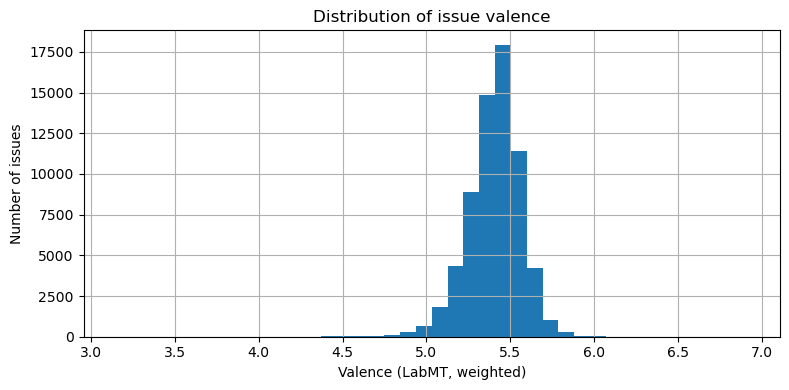

In [116]:
plt.figure(figsize=(8, 4))
valence_series.dropna().hist(bins=40)
plt.xlabel("Valence (LabMT, weighted)")
plt.ylabel("Number of issues")
plt.title("Distribution of issue valence")
plt.tight_layout()
plt.show()


## Top and bottom issues by valence

Identify the most positive and most negative issues according to the weighted valence.

Top 10 issues by valence:
 pd-21029    6.919103
tf-24225    6.495017
pd-1389     6.460764
pd-436      6.286351
tf-15015    6.160378
pd-1653     6.129283
tf-2009     6.124235
tf-3114     6.094363
pd-734      6.090687
tf-7406     6.089988
Name: valence, dtype: float64

Bottom 10 issues by valence:
 tf-6842     3.145673
tf-39347    3.252404
pd-16499    3.763957
pd-13128    3.765506
pd-18788    3.794114
pd-2462     3.829967
pd-4228     3.993339
pd-17013    4.038590
pd-840      4.043832
tf-38442    4.075091
Name: valence, dtype: float64


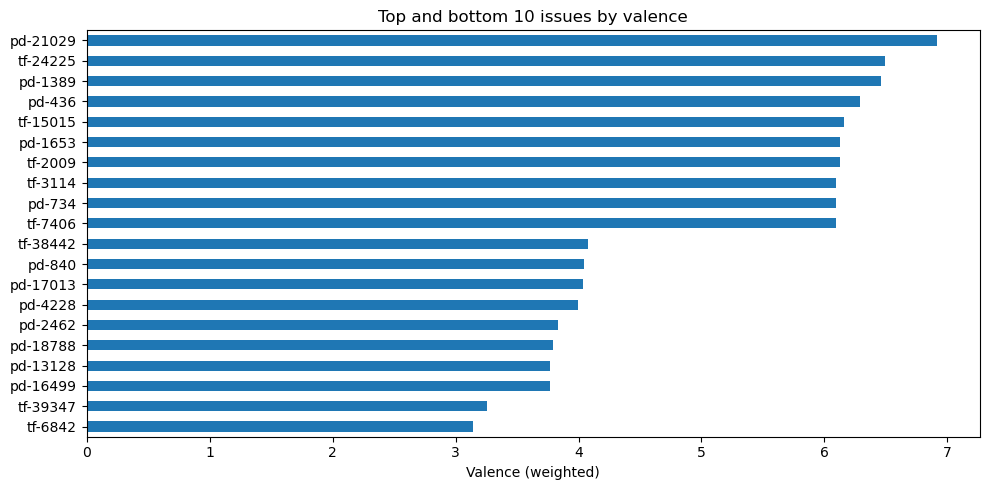

In [117]:
top_10 = valence_series.dropna().nlargest(10)
bottom_10 = valence_series.dropna().nsmallest(10)

print("Top 10 issues by valence:\n", top_10)
print("\nBottom 10 issues by valence:\n", bottom_10)

viz_data = pd.concat([top_10, bottom_10])
plt.figure(figsize=(10, 5))
viz_data.sort_values().plot(kind="barh")
plt.xlabel("Valence (weighted)")
plt.title("Top and bottom 10 issues by valence")
plt.tight_layout()
plt.show()


## Top TF-IDF terms for the highest-valence issue

Inspect which terms dominate the most positive issue according to TF-IDF.


=== Top 1 Issue ===
Issue ID: pd-21029
Valence: 6.919

Issue text:
BUG: len(map)
### Pandas version checks  - [X] I have checked that this issue has not already been reported.  - [X] I have confirmed this bug exists on the [latest version](https://pandas.pydata.org/docs/whatsnew/index.html) of pandas.  - [X] I have confirmed this bug exists on the [main branch](https://pandas.pydata.org/docs/dev/getting_started/install.html#installing-the-development-version-of-pandas) of pandas.   ### Reproducible Example  ```python import seaborn as sns  a=[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

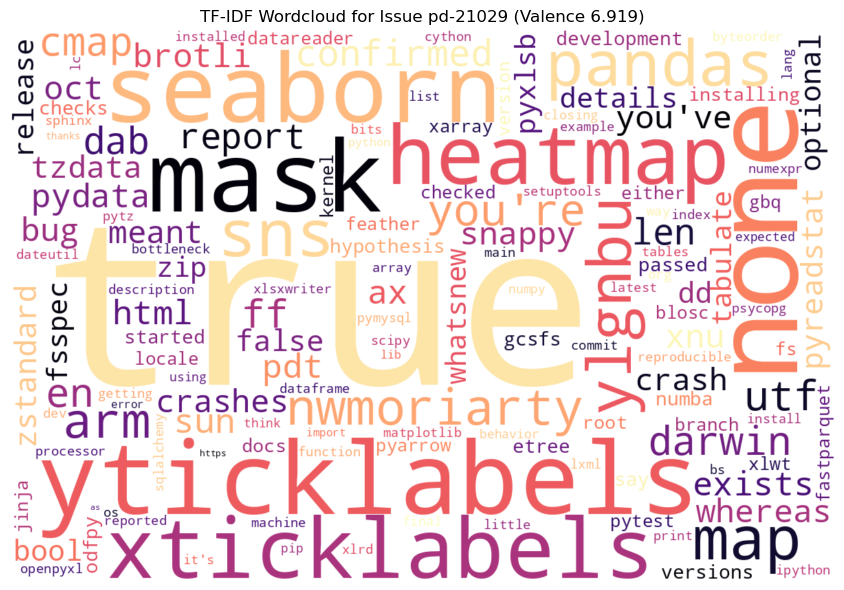


=== Top 2 Issue ===
Issue ID: tf-24225
Valence: 6.495

Issue text:
TF 2 libraries for Arduino IDE
@tensorflow/micro  The arduino library managers only provide tf 1.14 and 1.15 build-in libraries and hope tensorflow team could provide the tf 2 libraries for Arduino IDE. 

Valence score of top TF-IDF term 'arduino': N/A


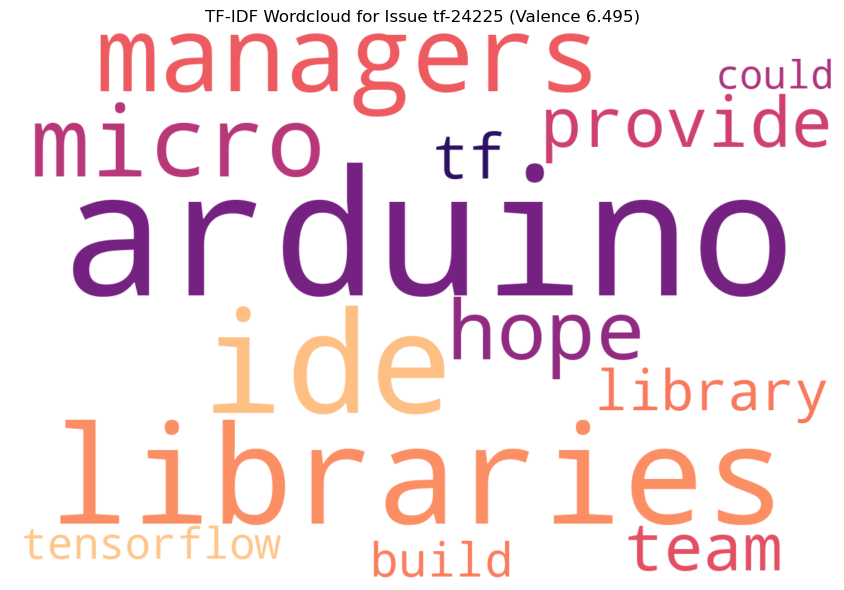


=== Top 3 Issue ===
Issue ID: pd-1389
Valence: 6.461

Issue text:
Odd unstack failure
Set day,time, smoker as index, unstack(2)  ``` day,time,smoker,sum,len Fri,Dinner,No,8.25,3 Fri,Dinner,Yes,27.03,9 Fri,Lunch,No,3.0,1 Fri,Lunch,Yes,13.68,6 Sat,Dinner,No,139.63,45 Sat,Dinner,Yes,120.77,42 Sun,Dinner,No,180.57,57 Sun,Dinner,Yes,66.82,19 Thur,Dinner,No,3.0,1 Thur,Lunch,No,117.32,44 Thur,Lunch,Yes,51.51,17 ```  

Valence score of top TF-IDF term 'dinner': 7.4


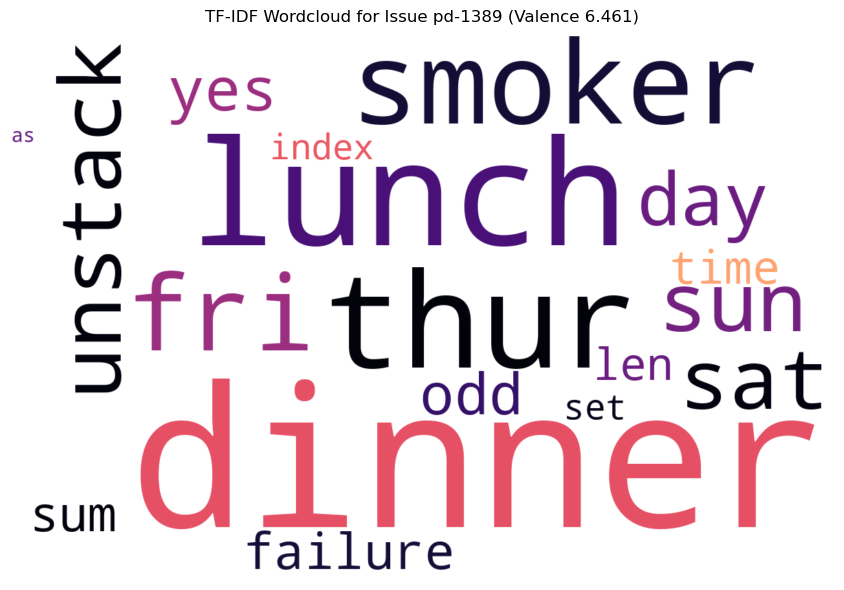


=== Top 4 Issue ===
Issue ID: pd-436
Valence: 6.286

Issue text:
read_csv performance regression
3x performance regression, likely b/c unicode changes  

Valence score of top TF-IDF term 'regression': N/A


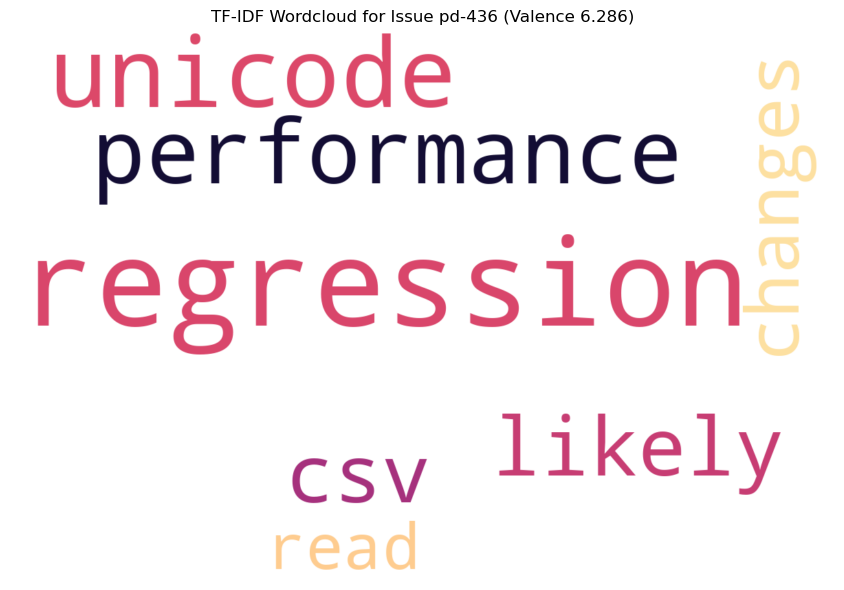


=== Top 5 Issue ===
Issue ID: tf-15015
Valence: 6.160

Issue text:
Any project about the evaluation of music or piano
Dear, Is there any project about evaluating the music or piano music, When we get many datasets of the same music from many people, How could we evaluate one of them,that is ,the label is the grad of the music is A ,B,C or D,  or just score between 0~100, Could we do something about this? Any advice or suggestion will be good. If U have any question,Please do not hesitate to tell me. Thx Probably you can take a look at [TensorFlow Magenta](https://magenta.tensorflow.org/). If you have specific questions related to Magenta project you can post it on [Magenta Github repo](https://github.com/tensorflow/magenta/issues). Thanks!

Valence score of top TF-IDF term 'music': 8.02


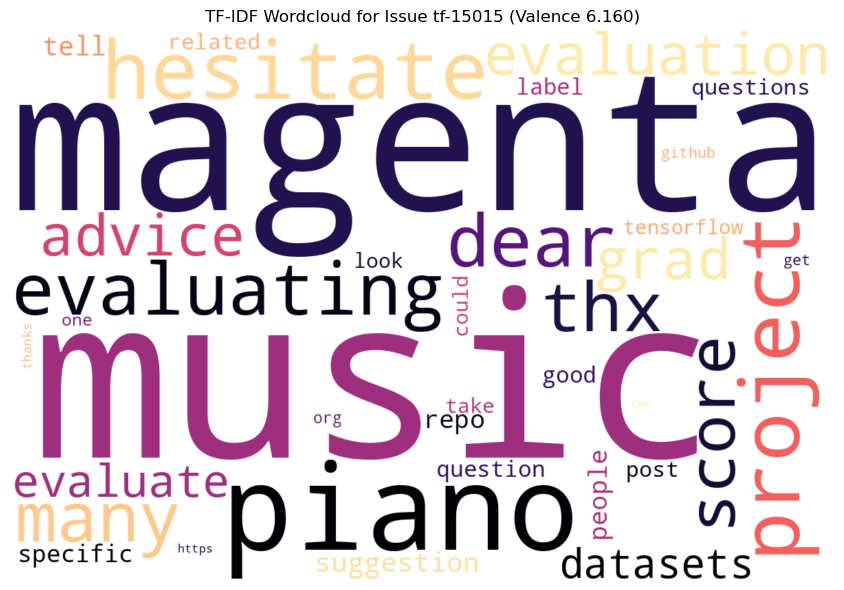

In [118]:
def plot_top_valence_issues_wordcloud(top5, all_df_processed, tfidf_per_issue, hedonometer_dict):
    for rank, (issue_id, val) in enumerate(top5.items(), start=1):
        print(f"\n=== Top {rank} Issue ===")
        print(f"Issue ID: {issue_id}")
        print(f"Valence: {val:.3f}")
        
        print("\nIssue text:")
        print(all_df_processed.loc[issue_id, "full_text"])
        
        best_tfidf = tfidf_per_issue.get(issue_id, {})
        
        if len(best_tfidf) > 0:
            top_word = max(best_tfidf, key=best_tfidf.get)
            top_word_val = hedonometer_dict.get(top_word, "N/A")
            print(f"\nValence score of top TF-IDF term '{top_word}': {top_word_val}")

        wc = WordCloud(width=1200, height=800, background_color="white",
            colormap="magma"
        ).generate_from_frequencies(best_tfidf)

        plt.figure(figsize=(10, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"TF-IDF Wordcloud for Issue {issue_id} (Valence {val:.3f})")
        plt.tight_layout()
        plt.show()

top5 = valence_series.dropna().nlargest(5)
plot_top_valence_issues_wordcloud(top5, all_df_processed, tfidf_per_issue, hedonometer_dict)

## Plotting the 5 issues with lowest sentiment


=== Top 1 Issue ===
Issue ID: tf-6842
Valence: 3.146

Issue text:
Tensorflow execution with HVX failed on Qualcomm 820 Board
@satok16 could you have a look at this error?   I have built the libs and am using Intrinsys 820 Qualcomm board. Tried your troubleshooting procedure to sign as well and put the .so file in `/system/lib/rfsa/adsp/`. Running hexagon graph gives me the same error :   ``` WARNING: linker: Warning: unable to normalize "" Running main() from test_main.cc Note: Google Test filter = GraphTransferer.RunInceptionV3OnHexagonExampleWithTfRuntime [==========] Running 1 test from 1 test case. [----------] Global test environment set-up. [----------] 1 test from GraphTransferer [ RUN      ] GraphTransferer.RunInceptionV3OnHexagonExampleWithTfRuntime native : hexagon_graph_execution_test.cc:445 Fuse and run inception v3 on hexagon with tf runtime tensorflow/core/kernels/hexagon/hexagon_graph_execution_test.cc:72: Failure Expected: (version) >= (1), actual: 0 vs 1 native : hexa

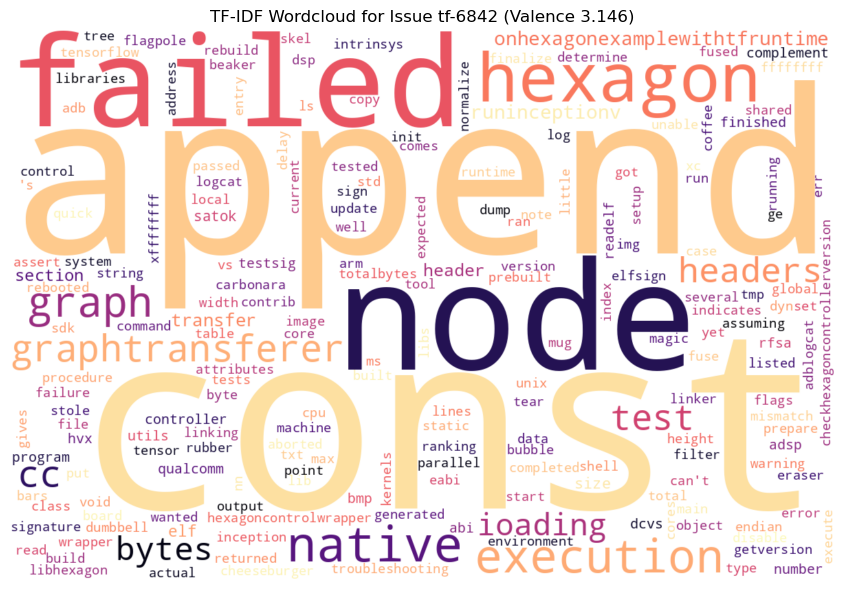


=== Top 2 Issue ===
Issue ID: tf-39347
Valence: 3.252

Issue text:
I am a spammer with no shame, I will spam your project
I am a spammer with no shame Why are you spamming?

Valence score of top TF-IDF term 'spammer': N/A


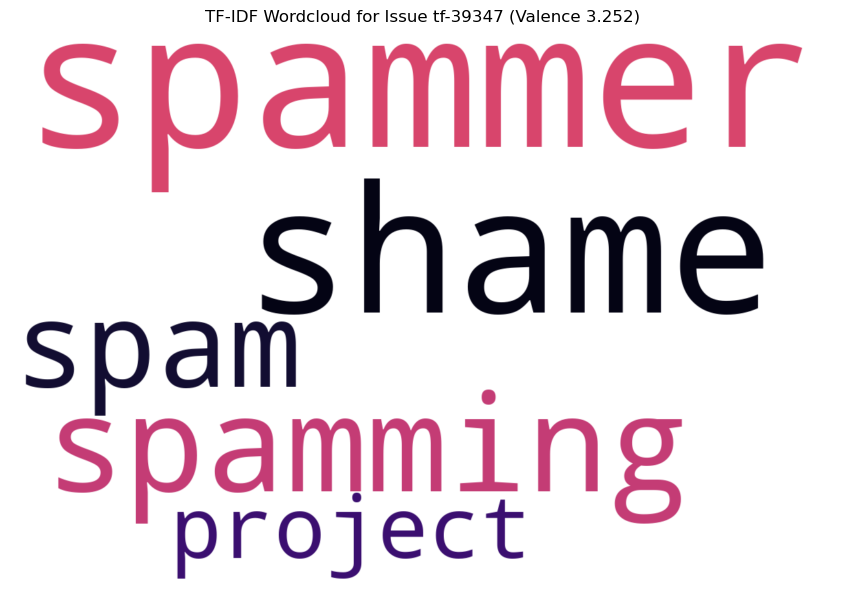


=== Top 3 Issue ===
Issue ID: pd-16499
Valence: 3.764

Issue text:
CI: Linux py36_locale failures with pytest DeprecationWarning
tests using `async_mark` are failing cc @alimcmaster1  ``` =========================== short test summary info ============================ ERROR pandas/tests/arrays/categorical/test_warnings.py::TestCategoricalWarnings ERROR pandas/tests/arrays/categorical/test_warnings.py::TestCategoricalWarnings ERROR pandas/tests/frame/test_api.py::TestDataFrameMisc - pytest.PytestDeprec... ERROR pandas/tests/frame/test_api.py::TestDataFrameMisc - pytest.PytestDeprec... ERROR pandas/tests/indexes/test_base.py::TestIndex - pytest.PytestDeprecation... ERROR pandas/tests/indexes/test_base.py::TestIndex - pytest.PytestDeprecation... ERROR pandas/tests/resample/test_resampler_grouper.py - pytest.PytestDeprecat... ERROR pandas/tests/resample/test_resampler_grouper.py - pytest.PytestDeprecat... ERROR pandas/tests/series/test_api.py::TestSeriesMisc - pytest.PytestDeprecat... ERR

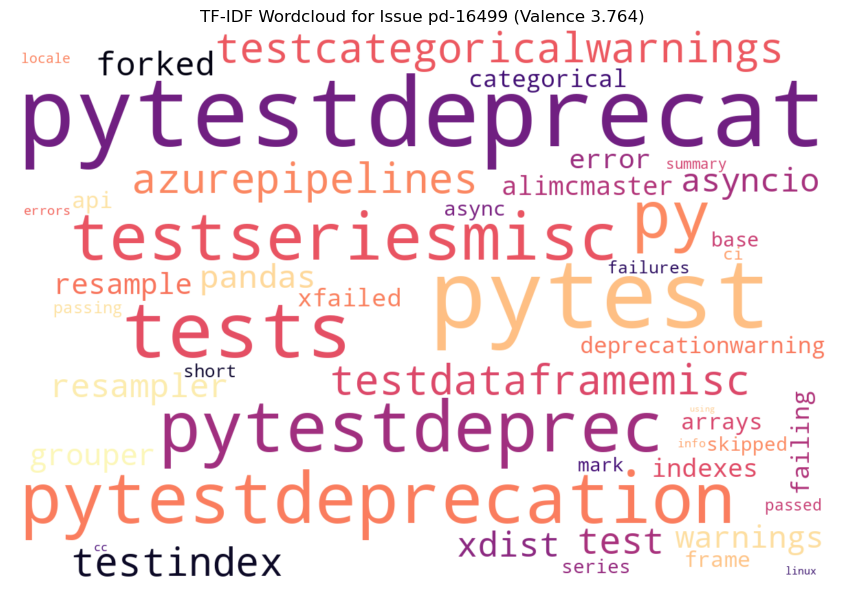


=== Top 4 Issue ===
Issue ID: pd-13128
Valence: 3.766

Issue text:
CI: Linting error
I'm working on #25424, after rebase to upstream/master, I get [linting errors](https://dev.azure.com/pandas-dev/pandas/_build/results?buildId=9370).  error F632,  E117 are simple fix. error F821 is type hints as flakes8 cannot detect buildin type.  I can fix as: a. add `#noqa` at the end line b. add build in option in setup.cfg ``` builtins =     _,     _LE,     _LW ```   ``` ##[error]./pandas/tests/indexes/interval/test_interval_tree.py(162,20): error F632: use ==/!= to compare str, bytes, and int literals ##[error]./pandas/tests/frame/test_alter_axes.py(204,32): error F632: use ==/!= to compare str, bytes, and int literals ##[error]./pandas/tests/frame/test_alter_axes.py(204,51): error F632: use ==/!= to compare str, bytes, and int literals ##[error]./pandas/tests/frame/test_alter_axes.py(1275,13): error E117: over-indented (comment) ##[error]./pandas/tests/io/test_pytables.py(2389,13): error E117: 

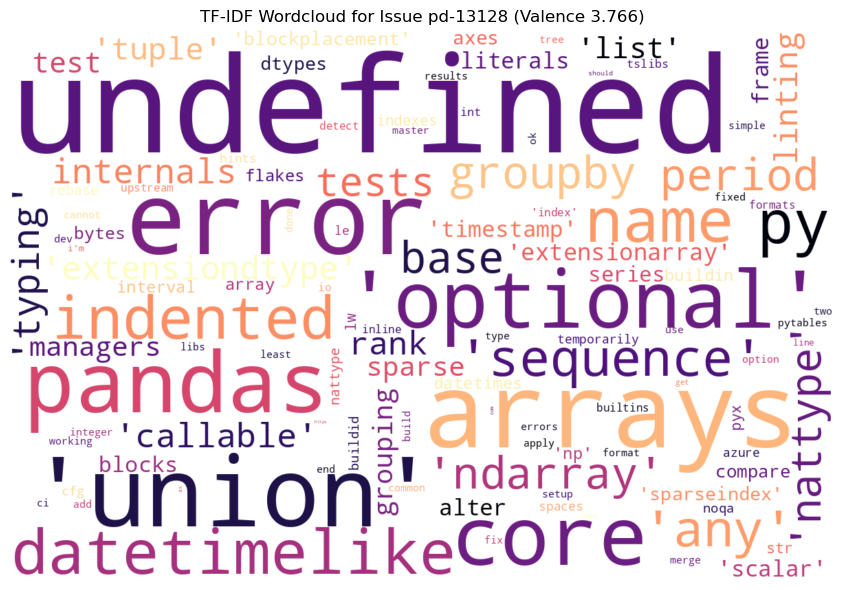


=== Top 5 Issue ===
Issue ID: pd-18788
Valence: 3.794

Issue text:
TST: Add doctests on cython files
Adding `--doctest-cython` to `ci/run_tests.sh` to cover doctests in cython files.  Lots of them are failing at the moment. But I think few of them (like now, today), can be skipped using `# doctest: +SKIP`.  Below is the current list of failures atm. ```python ===================================================================================== short test summary info ===================================================================================== FAILED pandas/_libs/hashtable.cpython-38-darwin.so::pandas._libs.hashtable.Int64Factorizer.factorize FAILED pandas/_libs/hashtable.cpython-38-darwin.so::pandas._libs.hashtable.ObjectFactorizer.factorize FAILED pandas/_libs/hashtable.cpython-38-darwin.so::pandas._libs.hashtable.__test__.Int64Factorizer.factorize (line 134) FAILED pandas/_libs/hashtable.cpython-38-darwin.so::pandas._libs.hashtable.__test__.ObjectFactorizer.factorize (line 

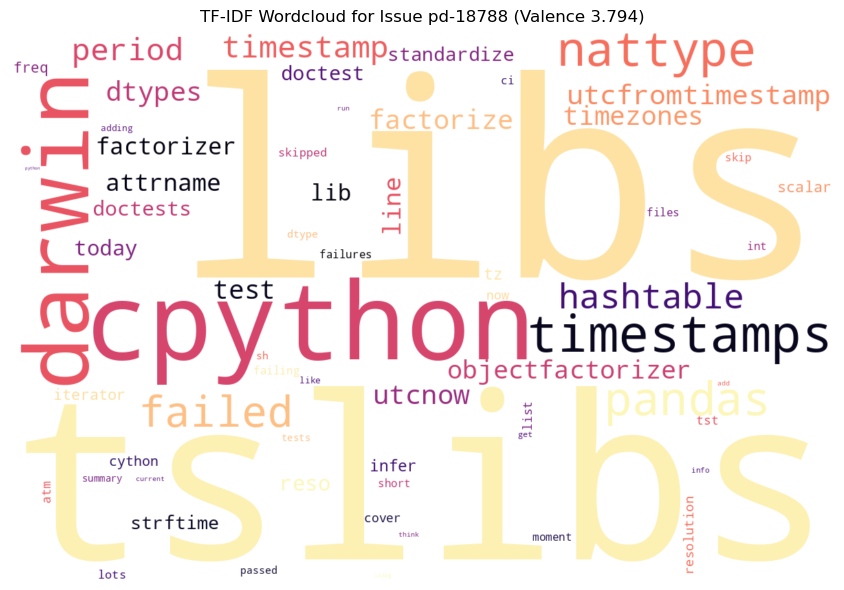

In [119]:
bottom5 = valence_series.dropna().nsmallest(5)
plot_top_valence_issues_wordcloud(bottom5, all_df_processed, tfidf_per_issue, hedonometer_dict)

## Compare Sentiment profiles per repository

Take average valence score per repo and compare to see which repo's are happier and which ones are sadder

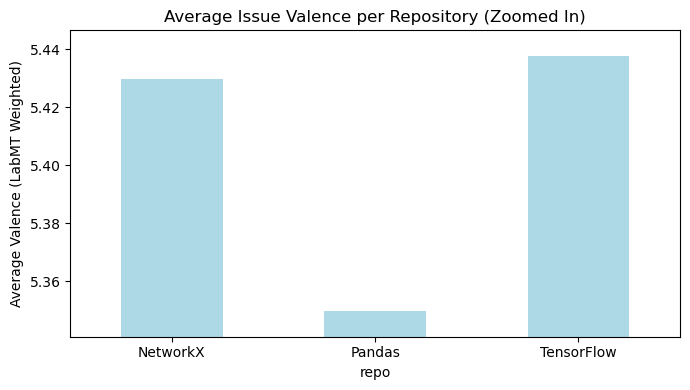

In [120]:
valence_df = pd.DataFrame(
    [(whatever, somevarorsumn) for whatever, somevarorsumn in issue_valence.items()],
    columns=["issue_id", "valence"]
)

valence_df["repo"] = valence_df["issue_id"].str[:2]

grouped = valence_df.groupby("repo")["valence"]

means = grouped.mean()
vars_ = grouped.var()
sizes = grouped.count()

grouped = valence_df.groupby("repo")["valence"]

vals_nx = grouped.get_group("nx").dropna().values
vals_pd = grouped.get_group("pd").dropna().values
vals_tf = grouped.get_group("tf").dropna().values

name_map = {
    "nx": "NetworkX",
    "pd": "Pandas",
    "tf": "TensorFlow"
}

avg_valence_named = means.rename(index=name_map)

min_val = avg_valence_named.min()
max_val = avg_valence_named.max()

padding = (max_val - min_val) * 0.1

plt.figure(figsize=(7,4))
avg_valence_named.plot(kind="bar", color="lightblue")

plt.ylabel("Average Valence (LabMT Weighted)")
plt.title("Average Issue Valence per Repository (Zoomed In)")
plt.xticks(rotation=0)

plt.ylim(min_val - padding, max_val + padding)

plt.tight_layout()
plt.show()

#### A Difference?


We see a very clear difference in Average Valence values between Pandas and NetworkX and TensorFlow, however do these values mean anything? To prove this we will calculate the P-values

In [121]:
print("Means:\n", means)
print("Variances:\n", vars_)
print("Sizes:\n", sizes)

pvals = {}

# nx vs pd
t_stat, p_val = ttest_ind(vals_nx, vals_pd, equal_var=False, nan_policy="omit")
pvals[("nx", "pd")] = (t_stat, p_val)

# nx vs tf
t_stat, p_val = ttest_ind(vals_nx, vals_tf, equal_var=False, nan_policy="omit")
pvals[("nx", "tf")] = (t_stat, p_val)

# pd vs tf
t_stat, p_val = ttest_ind(vals_pd, vals_tf, equal_var=False, nan_policy="omit")
pvals[("pd", "tf")] = (t_stat, p_val)

print("Pairwise Welch t-test results:")
for (a, b), (t_stat, p_val) in pvals.items():
    print(f"{a} vs {b}: t = {t_stat:.4f}, p = {p_val:.6g}")

Means:
 repo
nx    5.429934
pd    5.349723
tf    5.437759
Name: valence, dtype: float64
Variances:
 repo
nx    0.027824
pd    0.030009
tf    0.019869
Name: valence, dtype: float64
Sizes:
 repo
nx     3130
pd    23629
tf    39426
Name: valence, dtype: int64
Pairwise Welch t-test results:
nx vs pd: t = 25.1654, p = 5.07142e-130
nx vs tf: t = -2.5532, p = 0.0107165
pd vs tf: t = -66.0985, p = 0


## Compare TF-IDF profiles per repository

Aggregate TF-IDF scores per repo and inspect which terms are most characteristic for each repository.

In [122]:
repo_term_scores = defaultdict(lambda: defaultdict(float))

for issue_id, tfidf in tfidf_per_issue.items():
    repo = all_df_processed.loc[issue_id, "repo_name"]
    for term, score in tfidf.items():
        repo_term_scores[repo][term] += score

repo_top_terms = {}
for repo, term_scores in repo_term_scores.items():
    ranked = sorted(term_scores.items(), key=lambda kv: kv[1], reverse=True)[:50]
    repo_top_terms[repo] = ranked

## Visualize top TF-IDF terms per repository

Plot bar charts of the most characteristic terms for a few selected repositories.

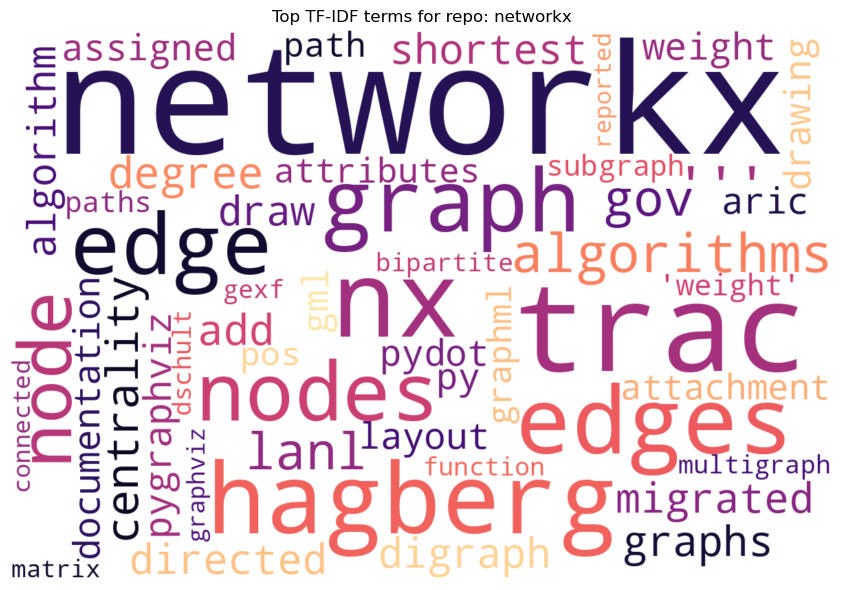

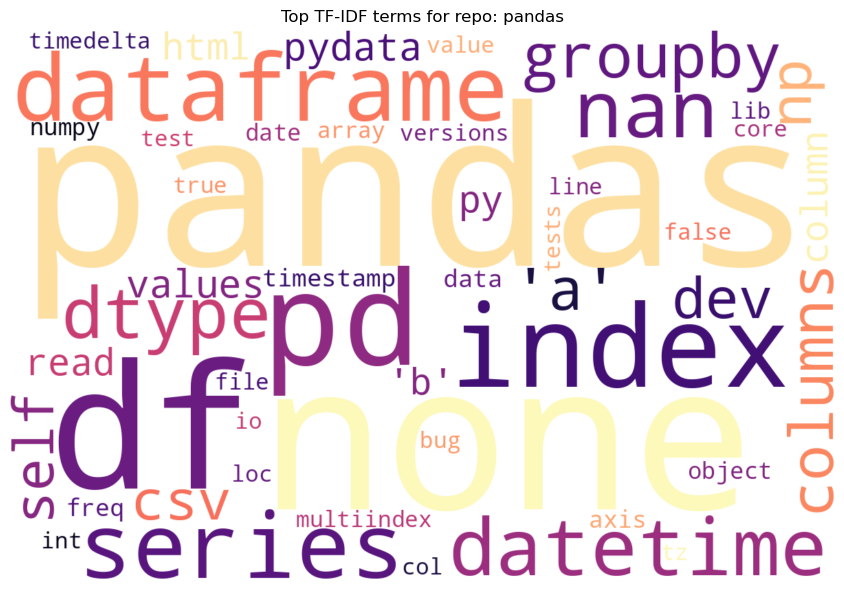

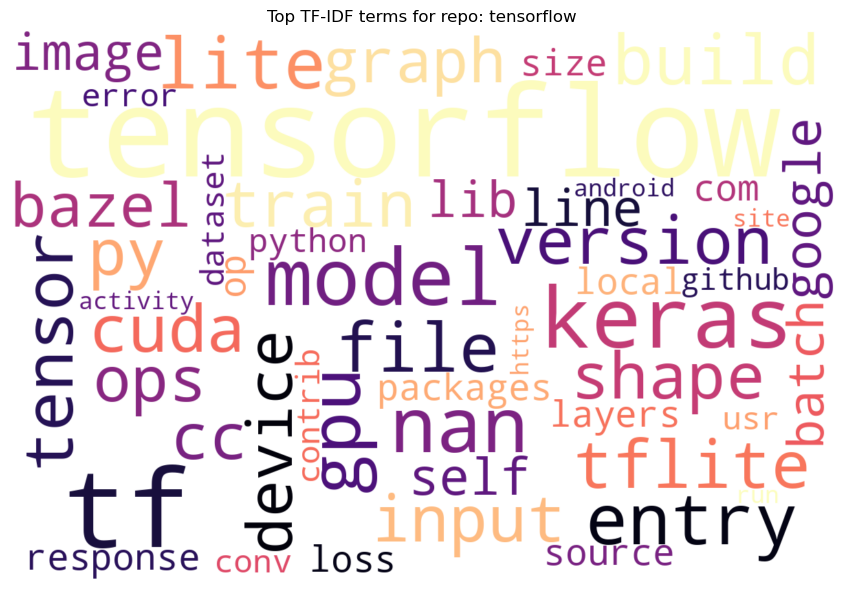

In [123]:
repos_to_plot = list(repo_top_terms.keys())

for repo in repos_to_plot:
    ranked = repo_top_terms[repo]

    freq_dict = dict(ranked)

    wc = WordCloud(
        width=1200,
        height=800,
        background_color="white",
        colormap="magma" # i rlly like the magma theme :)
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Top TF-IDF terms for repo: {repo}")
    plt.tight_layout()
    plt.show()


# Division of Work
Data requesting and network analysis: Ben Berger s252255

Applying TF-IDF and Sentiment Valence: Duco Lam s252126